In [1]:
import os
import itertools
import numpy as np
import pandas as pd
from scipy import stats

# --------------------------------------------------
# 1. SETTINGS
# --------------------------------------------------
technique_name   = "CRYO-SEM"
concentration    = "X3000"
methods_to_keep  = ["FREEHAND", "ILASTIK", "UNET"]

# Your exact folder paths for the 4 replicates
replicate_folders = [
    (1, r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X3000\CRYO-SEM X3000\CRYO-SEM X3000 [1]\CRYO-SEM X3000 Accuracy"),
    (2, r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X3000\CRYO-SEM X3000\CRYO-SEM X3000 [2]\CRYO-SEM X3000 [2] Accuracy"),
    (3, r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X3000\CRYO-SEM X3000\CRYO-SEM X3000 [3]\CRYO-SEM X3000 [3] Accuracy"),
    (4, r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X3000\CRYO-SEM X3000\CRYO-SEM X3000 [4]\CRYO-SEM X3000 [4] Accuracy"),
]

# File names for the three methods
file_map = {
    "FREEHAND": "Metric Results [FREEHAND].csv",
    "ILASTIK":  "Metric Results [ILASTIK].csv",
    "UNET":     "Metric Results [UNET].csv",
}

# If you want to tag families (optional)
family_map = {
    "FREEHAND": "Traditional",
    "ILASTIK":  "Semi-automated",
    "UNET":     "Fully automated",
}

# --------------------------------------------------
# 2. LOAD ALL CSVs INTO ONE DATAFRAME
# --------------------------------------------------
rows = []

for rep, folder in replicate_folders:
    print(f"\nReplicate {rep} folder: {folder}")
    if not os.path.isdir(folder):
        print(f"  WARNING: folder does not exist: {folder}")
        continue

    for method in methods_to_keep:
        fname = file_map[method]
        fpath = os.path.join(folder, fname)
        if not os.path.isfile(fpath):
            print(f"  WARNING: file not found: {fname}")
            continue

        print(f"  Loading: {fname}")
        df = pd.read_csv(fpath)

        # Expected metric/value columns; adjust if needed
        # Assume columns: 'metric', 'value'
        # If your CSV uses different names, change here.
        if "metric" not in df.columns or "value" not in df.columns:
            raise RuntimeError(f"CSV format unexpected in {fpath}")

        df = df[["metric", "value"]].copy()
        df["technique"]     = technique_name
        df["concentration"] = concentration
        df["replicate"]     = rep
        df["method"]        = method
        df["family"]        = family_map.get(method, "Unknown")
        df["file_source"]   = fname

        rows.append(df)

if not rows:
    raise RuntimeError("No data loaded – check paths / filenames!")

results = pd.concat(rows, ignore_index=True)
print("\nLoaded rows:", len(results))
print(results.head())

# --------------------------------------------------
# 3. FUNCTION: HOLM CORRECTION
# --------------------------------------------------
def holm_correction(pvals):
    """
    Holm–Bonferroni correction.
    pvals: list of raw p-values
    returns: list of Holm-adjusted p-values in original order
    """
    m = len(pvals)
    order = np.argsort(pvals)
    sorted_p = np.array(pvals)[order]
    adjusted = np.empty(m)

    # step-down Holm
    for i, p in enumerate(sorted_p):
        adjusted[i] = (m - i) * p

    # enforce monotonicity
    for i in range(1, m):
        adjusted[i] = max(adjusted[i], adjusted[i-1])

    adjusted = np.minimum(adjusted, 1.0)

    # return to original order
    out = np.empty(m)
    out[order] = adjusted
    return out.tolist()

# --------------------------------------------------
# 4. STATS: CRYO-SEM X3000, 3 METHODS
# --------------------------------------------------
print("\n=== ANALYSIS: FREEHAND vs ILASTIK vs UNET (CRYO-SEM X3000, repl 1–4) ===")
print("Methods found:", sorted(results["method"].unique()))

metrics = sorted(results["metric"].unique())

for metric in metrics:
    print("\n-------------------------------------")
    print(f"Metric: {metric}")

    sub = results[results["metric"] == metric].copy()

    # Quick summary
    summary = (
        sub.groupby("method")["value"]
        .agg(["count", "mean", "median", "std", "min", "max"])
    )
    print("\nSummary stats:")
    print(summary)

    # Kruskal–Wallis across the three methods
    groups = []
    labels = []
    for m in methods_to_keep:
        vals = sub[sub["method"] == m]["value"].values
        if len(vals) > 0:
            groups.append(vals)
            labels.append(m)

    if len(groups) < 2:
        print("\nNot enough methods with data for this metric.")
        continue

    H, p_kw = stats.kruskal(*groups)
    print(f"\nKruskal–Wallis: H={H:.4f}  p={p_kw:.6f}")
    if p_kw < 0.05:
        print("→ Significant global difference between the three methods.")
    else:
        print("→ No significant global difference between the three methods.")

    # Pairwise Mann–Whitney with Holm correction
    pairs = list(itertools.combinations(labels, 2))
    p_raw = []
    U_stats = []

    for m1, m2 in pairs:
        v1 = sub[sub["method"] == m1]["value"].values
        v2 = sub[sub["method"] == m2]["value"].values
        if len(v1) == 0 or len(v2) == 0:
            p_raw.append(np.nan)
            U_stats.append(np.nan)
            continue
        U, p = stats.mannwhitneyu(v1, v2, alternative="two-sided")
        p_raw.append(p)
        U_stats.append(U)

    p_holm = holm_correction(p_raw)

    pair_rows = []
    for (m1, m2), p_r, p_h, U in zip(pairs, p_raw, p_holm, U_stats):
        pair_rows.append({
            "m1": m1,
            "m2": m2,
            "p_raw": p_r,
            "U": U,
            "p_holm": p_h,
            "sig_raw":  p_r < 0.05,
            "sig_holm": p_h < 0.05,
        })

    pair_df = pd.DataFrame(pair_rows)
    print("\nPairwise tests (Mann–Whitney, Holm-corrected):")
    print(pair_df.to_string(index=False))


Replicate 1 folder: C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X3000\CRYO-SEM X3000\CRYO-SEM X3000 [1]\CRYO-SEM X3000 Accuracy
  Loading: Metric Results [FREEHAND].csv
  Loading: Metric Results [ILASTIK].csv
  Loading: Metric Results [UNET].csv

Replicate 2 folder: C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X3000\CRYO-SEM X3000\CRYO-SEM X3000 [2]\CRYO-SEM X3000 [2] Accuracy
  Loading: Metric Results [FREEHAND].csv
  Loading: Metric Results [ILASTIK].csv
  Loading: Metric Results [UNET].csv

Replicate 3 folder: C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X3000\CRYO-SEM X3000\CRYO-SEM X3000 [3]\CRYO-SEM X3000 [3] Accuracy
  Loading: Metric Results [FREEHAND].csv
  Loading: Metric Results [ILASTIK].csv
  Loading: Metric Results [UNET].csv

Replicate 4 folder: C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SE

In [2]:
import os
import itertools
import numpy as np
import pandas as pd
from scipy import stats

# --------------------------------------------------
# 1. SETTINGS
# --------------------------------------------------
technique_name   = "CRYO-SEM"
concentration    = "Mixed magnifications"

# All segmentation methods to include
# Note: PLANKSTER is reported as "PHANSALKAR"
methods_to_keep  = [
    "60%",
    "FREEHAND",
    "ILASTIK",
    "OTSU",
    "OVAL",
    "PHANSALKAR",  # loads PLANKSTER file
    "PORED2",
    "SAMJ",
    "SEMI",
    "UNET",
]

# Your exact folder paths for ALL replicates (X3000, X10000, X30000, X60000; 4 each)
replicate_folders = [
    # X3000
    (1,  r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X3000\CRYO-SEM X3000\CRYO-SEM X3000 [1]\CRYO-SEM X3000 Accuracy"),
    (2,  r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X3000\CRYO-SEM X3000\CRYO-SEM X3000 [2]\CRYO-SEM X3000 [2] Accuracy"),
    (3,  r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X3000\CRYO-SEM X3000\CRYO-SEM X3000 [3]\CRYO-SEM X3000 [3] Accuracy"),
    (4,  r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X3000\CRYO-SEM X3000\CRYO-SEM X3000 [4]\CRYO-SEM X3000 [4] Accuracy"),

    # X10000
    (5,  r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X10000\CRYO-SEM X10000 [1]\CRYO-SEM X10000 [1] Accuracy"),
    (6,  r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X10000\CRYO-SEM X10000 [2]\CRYO-SEM X10000 [2] Accuracy"),
    (7,  r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X10000\CRYO-SEM X10000 [3]\CRYO-SEM X10000 [3] Accuracy"),
    (8,  r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X10000\CRYO-SEM X10000 [4]\CRYO-SEM X10000 [4] Accuracy"),

    # X30000
    (9,  r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X30000\CRYO-SEM X30000 [1]\CRYO-SEM X30000 [1] Accuracy"),
    (10, r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X30000\CRYO-SEM X30000 [2]\CRYO-SEM X30000 [2] Accuracy"),
    (11, r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X30000\CRYO-SEM X30000 [3]\CRYO-SEM X30000 [3] Accuracy"),
    (12, r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X30000\CRYO-SEM X30000 [4]\CRYO-SEM X30000 [4] Accuracy"),

    # X60000
    (13, r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X60000\CRYO-SEM X60000 [1]\CRYO-SEM X60000 [1] Accuracy"),
    (14, r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X60000\CRYO-SEM X60000 [2]\CRYO-SEM X60000 [2] Accuracy"),
    (15, r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X60000\CRYO-SEM X60000 [3]\CRYO-SEM X60000 [3] Accuracy"),
    (16, r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X60000\CRYO-SEM X60000 [4]\CRYO-SEM X60000 [4] Accuracy"),
]

# File names for each method
file_map = {
    "60%"        : "Metric Results [60%].csv",
    "FREEHAND"   : "Metric Results [FREEHAND].csv",
    "ILASTIK"    : "Metric Results [ILASTIK].csv",
    "OTSU"       : "Metric Results [OTSU].csv",
    "OVAL"       : "Metric Results [OVAL].csv",
    "PHANSALKAR" : "Metric Results [PLANKSTER].csv",  # note the rename
    "PORED2"     : "Metric Results [PORED2].csv",
    "SAMJ"       : "Metric Results [SAMJ].csv",
    "SEMI"       : "Metric Results [SEMI].csv",
    "UNET"       : "Metric Results [UNET].csv",
}

# Correct family tags
family_map = {
    # Traditional
    "FREEHAND":   "Traditional",
    "OVAL":       "Traditional",

    # Semi-automated
    "ILASTIK":    "Semi-automated",
    "60%":        "Semi-automated",
    "SAMJ":       "Semi-automated",
    "SEMI":       "Semi-automated",

    # Fully automated
    "PORED2":     "Fully automated",
    "OTSU":       "Fully automated",
    "PHANSALKAR": "Fully automated",

    # Leave UNET as its own fully automated deep model
    "UNET":       "Fully automated",
}

# --------------------------------------------------
# 2. LOAD ALL CSVs INTO ONE DATAFRAME
# --------------------------------------------------
rows = []

for rep, folder in replicate_folders:
    print(f"\nReplicate {rep} folder: {folder}")
    if not os.path.isdir(folder):
        print(f"  WARNING: folder does not exist: {folder}")
        continue

    for method in methods_to_keep:
        fname = file_map[method]
        fpath = os.path.join(folder, fname)
        if not os.path.isfile(fpath):
            print(f"  WARNING: file not found: {fname}")
            continue

        print(f"  Loading: {fname}")
        df = pd.read_csv(fpath)

        # Expected metric/value columns; adjust if needed
        if "metric" not in df.columns or "value" not in df.columns:
            raise RuntimeError(f"CSV format unexpected in {fpath}")

        df = df[["metric", "value"]].copy()
        df["technique"]     = technique_name
        df["concentration"] = concentration
        df["replicate"]     = rep
        df["method"]        = method
        df["family"]        = family_map.get(method, "Unknown")
        df["file_source"]   = fname

        rows.append(df)

if not rows:
    raise RuntimeError("No data loaded – check paths / filenames!")

results = pd.concat(rows, ignore_index=True)
print("\nLoaded rows:", len(results))
print(results.head())

# --------------------------------------------------
# 3. FUNCTION: HOLM CORRECTION
# --------------------------------------------------
def holm_correction(pvals):
    """
    Holm–Bonferroni correction.
    pvals: list of raw p-values
    returns: list of Holm-adjusted p-values in original order
    """
    m = len(pvals)
    order = np.argsort(pvals)
    sorted_p = np.array(pvals)[order]
    adjusted = np.empty(m)

    # step-down Holm
    for i, p in enumerate(sorted_p):
        adjusted[i] = (m - i) * p

    # enforce monotonicity
    for i in range(1, m):
        adjusted[i] = max(adjusted[i], adjusted[i-1])

    adjusted = np.minimum(adjusted, 1.0)

    # return to original order
    out = np.empty(m)
    out[order] = adjusted
    return out.tolist()

# --------------------------------------------------
# 4. STATS: CRYO-SEM, ALL METHODS, ALL REPLICATES
#     (only performance metrics, no TP/TN/FP/FN)
# --------------------------------------------------
print("\n=== ANALYSIS: All methods (CRYO-SEM, all magnifications, repl 1–16) ===")
print("Methods found:", sorted(results["method"].unique()))

exclude_metrics = {"TP", "TN", "FP", "FN"}
metrics = sorted(m for m in results["metric"].unique() if m not in exclude_metrics)

for metric in metrics:
    print("\n-------------------------------------")
    print(f"Metric: {metric}")

    sub = results[results["metric"] == metric].copy()

    # Quick summary
    summary = (
        sub.groupby("method")["value"]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .sort_index()
    )
    print("\nSummary stats:")
    print(summary)

    # Kruskal–Wallis across all methods with data
    groups = []
    labels = []
    for m in methods_to_keep:
        vals = sub[sub["method"] == m]["value"].values
        if len(vals) > 0:
            groups.append(vals)
            labels.append(m)

    if len(groups) < 2:
        print("\nNot enough methods with data for this metric.")
        continue

    H, p_kw = stats.kruskal(*groups)
    print(f"\nKruskal–Wallis: H={H:.4f}  p={p_kw:.6f}")
    if p_kw < 0.05:
        print("→ Significant global difference between the methods.")
    else:
        print("→ No significant global difference between the methods.")

    # Pairwise Mann–Whitney with Holm correction
    pairs = list(itertools.combinations(labels, 2))
    p_raw = []
    U_stats = []

    for m1, m2 in pairs:
        v1 = sub[sub["method"] == m1]["value"].values
        v2 = sub[sub["method"] == m2]["value"].values
        if len(v1) == 0 or len(v2) == 0:
            p_raw.append(np.nan)
            U_stats.append(np.nan)
            continue
        U, p = stats.mannwhitneyu(v1, v2, alternative="two-sided")
        p_raw.append(p)
        U_stats.append(U)

    p_holm = holm_correction(p_raw)

    pair_rows = []
    for (m1, m2), p_r, p_h, U in zip(pairs, p_raw, p_holm, U_stats):
        pair_rows.append({
            "m1": m1,
            "m2": m2,
            "p_raw": p_r,
            "U": U,
            "p_holm": p_h,
            "sig_raw":  (p_r < 0.05) if not np.isnan(p_r) else np.nan,
            "sig_holm": (p_h < 0.05) if not np.isnan(p_h) else np.nan,
        })

    pair_df = pd.DataFrame(pair_rows)
    print("\nPairwise tests (Mann–Whitney, Holm-corrected):")
    print(pair_df.to_string(index=False))


Replicate 1 folder: C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X3000\CRYO-SEM X3000\CRYO-SEM X3000 [1]\CRYO-SEM X3000 Accuracy
  Loading: Metric Results [60%].csv
  Loading: Metric Results [FREEHAND].csv
  Loading: Metric Results [ILASTIK].csv
  Loading: Metric Results [OTSU].csv
  Loading: Metric Results [OVAL].csv
  Loading: Metric Results [PLANKSTER].csv
  Loading: Metric Results [PORED2].csv
  Loading: Metric Results [UNET].csv

Replicate 2 folder: C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X3000\CRYO-SEM X3000\CRYO-SEM X3000 [2]\CRYO-SEM X3000 [2] Accuracy
  Loading: Metric Results [60%].csv
  Loading: Metric Results [FREEHAND].csv
  Loading: Metric Results [ILASTIK].csv
  Loading: Metric Results [OTSU].csv
  Loading: Metric Results [OVAL].csv
  Loading: Metric Results [PLANKSTER].csv
  Loading: Metric Results [PORED2].csv
  Loading: Metric Results [UNET].csv

Replicate 3 folder: C:\Us

Saved to: C:\Users\walsh\Downloads\CryoSEM_segmentation_times.png


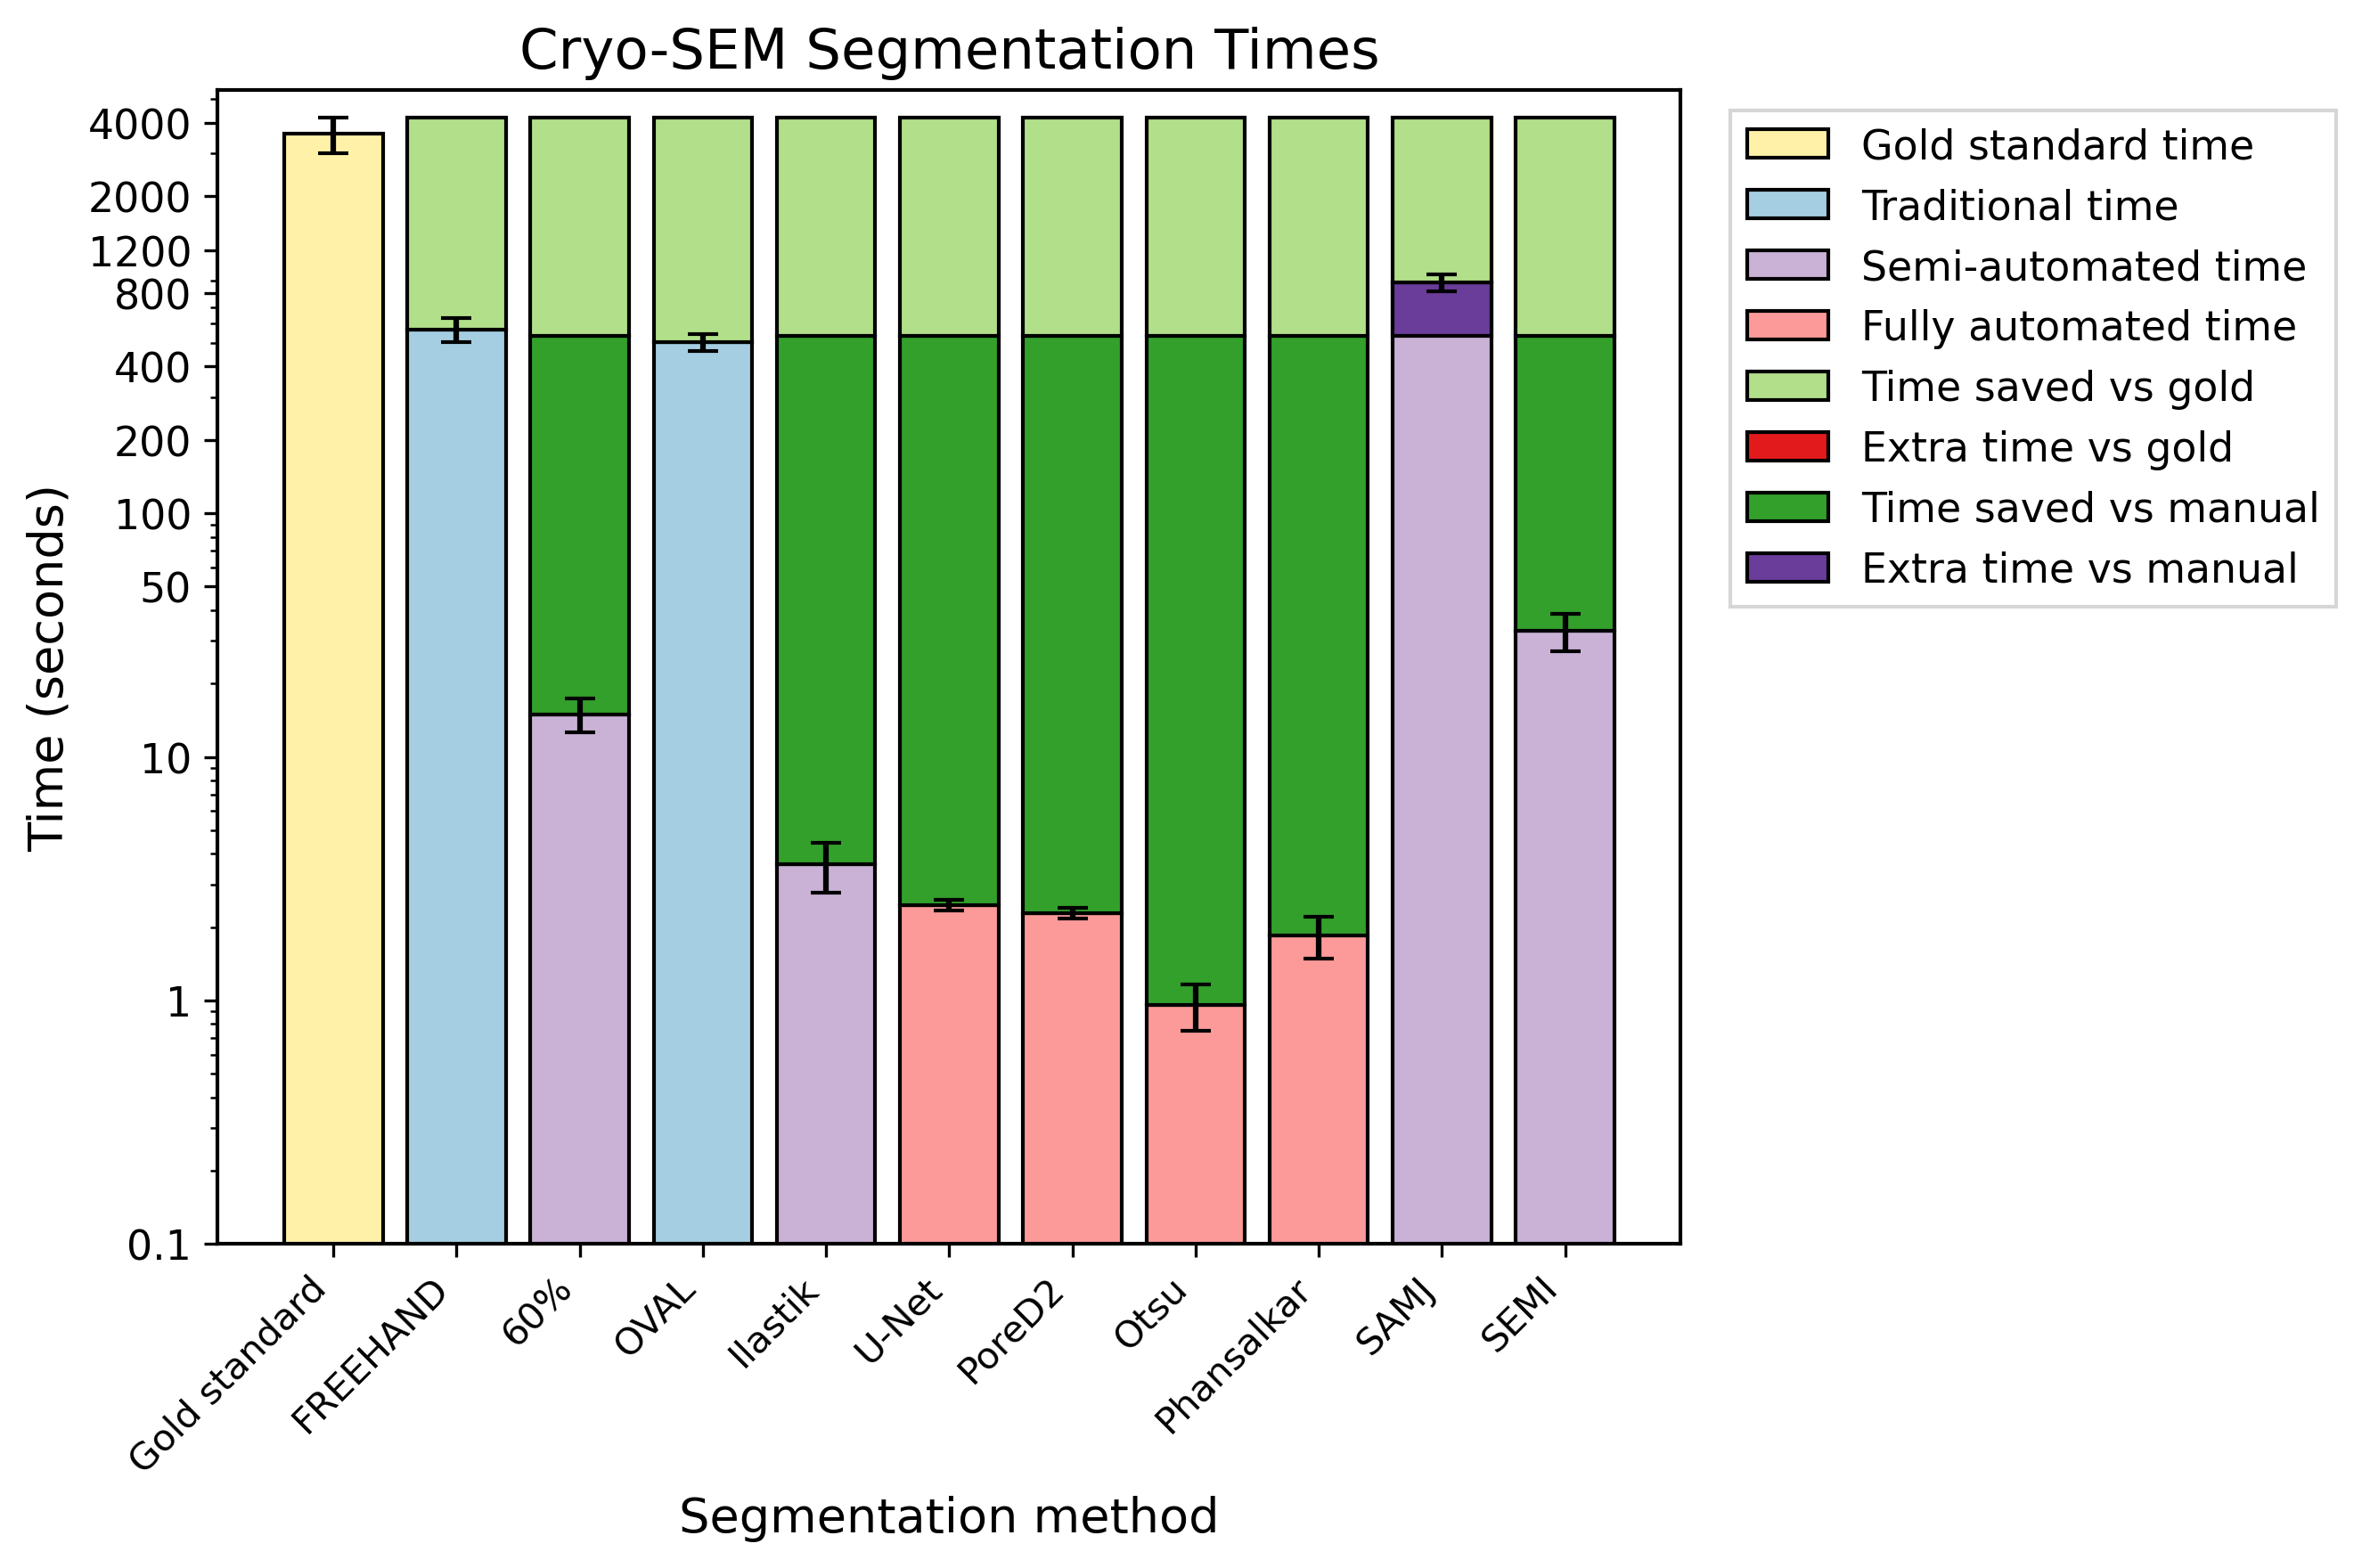

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# -------------------------------------------------------
# DATA (means, SDs)
# -------------------------------------------------------
data = {
    "Cryo-SEM": {
        "FREEHAND": (568.442, 63.552),
        "OVAL": (503.118, 41.229),
        "SEMI": (32.914, 5.822),
        "SAMJ": (883.557, 72.441),
        "Ilastik": (3.612, 0.842),
        "60%": (14.982, 2.336),
        "Phansalkar": (1.842, 0.362),
        "Otsu": (0.958, 0.209),
        "PoreD2": (2.287, 0.112),
        "U-Net": (2.466, 0.118),
    }
}

# -------------------------------------------------------
# ADD GOLD STANDARD (~1 hour)
# -------------------------------------------------------
data["Cryo-SEM"]["Gold standard"] = (3600.0, 600.0)

# -------------------------------------------------------
# CATEGORY COLORS
# -------------------------------------------------------
categories = {
    "Gold standard": "Gold standard",
    "FREEHAND": "Traditional",
    "OVAL": "Traditional",
    "SEMI": "Semi-automated",
    "SAMJ": "Semi-automated",
    "Ilastik": "Semi-automated",
    "60%": "Semi-automated",
    "Phansalkar": "Fully-automated",
    "Otsu": "Fully-automated",
    "PoreD2": "Fully-automated",
    "U-Net": "Fully-automated",
}

category_colors = {
    "Gold standard": "#fff2a8",  # lighter yellow
    "Traditional": "#a6cee3",
    "Semi-automated": "#cab2d6",
    "Fully-automated": "#fb9a99",
}

method_order = [
    "Gold standard",
    "FREEHAND", "60%", "OVAL", "Ilastik",
    "U-Net", "PoreD2", "Otsu", "Phansalkar",
    "SAMJ", "SEMI"
]

# -------------------------------------------------------
# SAVINGS / EXTRA COLORS
# -------------------------------------------------------
saved_vs_gold_color   = "#b2df8a"
extra_vs_gold_color   = "#e31a1c"
saved_vs_manual_color = "#33a02c"
extra_vs_manual_color = "#6a3d9a"

legend_handles = [
    Patch(facecolor=category_colors["Gold standard"], edgecolor="black", label="Gold standard time"),
    Patch(facecolor=category_colors["Traditional"], edgecolor="black", label="Traditional time"),
    Patch(facecolor=category_colors["Semi-automated"], edgecolor="black", label="Semi-automated time"),
    Patch(facecolor=category_colors["Fully-automated"], edgecolor="black", label="Fully automated time"),
    Patch(facecolor=saved_vs_gold_color, edgecolor="black", label="Time saved vs gold"),
    Patch(facecolor=extra_vs_gold_color, edgecolor="black", label="Extra time vs gold"),
    Patch(facecolor=saved_vs_manual_color, edgecolor="black", label="Time saved vs manual"),
    Patch(facecolor=extra_vs_manual_color, edgecolor="black", label="Extra time vs manual"),
]

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
})

yticks = [0.1, 1, 10, 50, 100, 200, 400, 800, 1200, 2000, 4000, 6000]

# -------------------------------------------------------
# PLOT
# -------------------------------------------------------
results = data["Cryo-SEM"]

means = [results[m][0] for m in method_order]
sds   = [results[m][1] for m in method_order]
x = np.arange(len(method_order))
colors = [category_colors[categories[m]] for m in method_order]

fig, ax = plt.subplots(figsize=(9, 6))

gold_mean, gold_sd = results["Gold standard"]
gold_cap = gold_mean + gold_sd

manual_ref = np.mean([
    results["FREEHAND"][0],
    results["OVAL"][0]
])

# -------------------------------------------------------
# GOLD STANDARD BAR
# -------------------------------------------------------
ax.bar(
    x[0], gold_mean,
    yerr=gold_sd,
    capsize=4,
    color=colors[0],
    edgecolor="black",
    linewidth=1,
)

# -------------------------------------------------------
# OTHER METHODS
# -------------------------------------------------------
for i in range(1, len(method_order)):

    m = method_order[i]
    actual = means[i]
    err = sds[i]

    ax.bar(
        x[i], actual,
        yerr=err,
        capsize=4,
        color=colors[i],
        edgecolor="black",
        linewidth=1,
    )

    top_stack = actual

    # ---------------------------------------------------
    # MANUAL COMPARISON (CORRECTED LOGIC)
    # ---------------------------------------------------
    if m not in ["FREEHAND", "OVAL"]:

        diff_manual = manual_ref - actual

        # Time saved vs manual
        if diff_manual > 0:

            ax.bar(
                x[i],
                diff_manual,
                bottom=actual,
                color=saved_vs_manual_color,
                edgecolor="black",
                linewidth=1,
            )

            top_stack = actual + diff_manual

        # Extra time vs manual (ONLY portion above manual)
        elif diff_manual < 0:

            extra_height = actual - manual_ref

            ax.bar(
                x[i],
                extra_height,
                bottom=manual_ref,
                color=extra_vs_manual_color,
                edgecolor="black",
                linewidth=1,
            )

            top_stack = actual

        else:
            top_stack = actual

    # ---------------------------------------------------
    # GOLD CAP FILL
    # ---------------------------------------------------
    remaining_to_cap = gold_cap - top_stack

    if remaining_to_cap > 0:
        ax.bar(
            x[i],
            remaining_to_cap,
            bottom=top_stack,
            color=saved_vs_gold_color,
            edgecolor="black",
            linewidth=1,
        )

# -------------------------------------------------------
# AXIS — LOG SCALE
# -------------------------------------------------------
ax.set_yscale("log")

upper_limit = gold_cap * 1.3
extended_yticks = yticks + [8000, 10000]

ax.set_yticks(extended_yticks)
ax.get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{v:g}")
)

ax.set_ylim(0.1, upper_limit)

# -------------------------------------------------------
# LABELS / LEGEND
# -------------------------------------------------------
ax.set_xlabel("Segmentation method")
ax.set_ylabel("Time (seconds)")
ax.set_title("Cryo-SEM Segmentation Times")

ax.set_xticks(x)
ax.set_xticklabels(method_order, rotation=45, ha="right")

for spine in ax.spines.values():
    spine.set_linewidth(1)
    spine.set_visible(True)

ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    fancybox=False,
)

plt.tight_layout()

# -------------------------------------------------------
# SAVE PNG TO DOWNLOADS
# -------------------------------------------------------
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
file_path = os.path.join(downloads_path, "CryoSEM_segmentation_times.png")

plt.savefig(file_path, dpi=300, bbox_inches="tight")
print(f"Saved to: {file_path}")

plt.show()

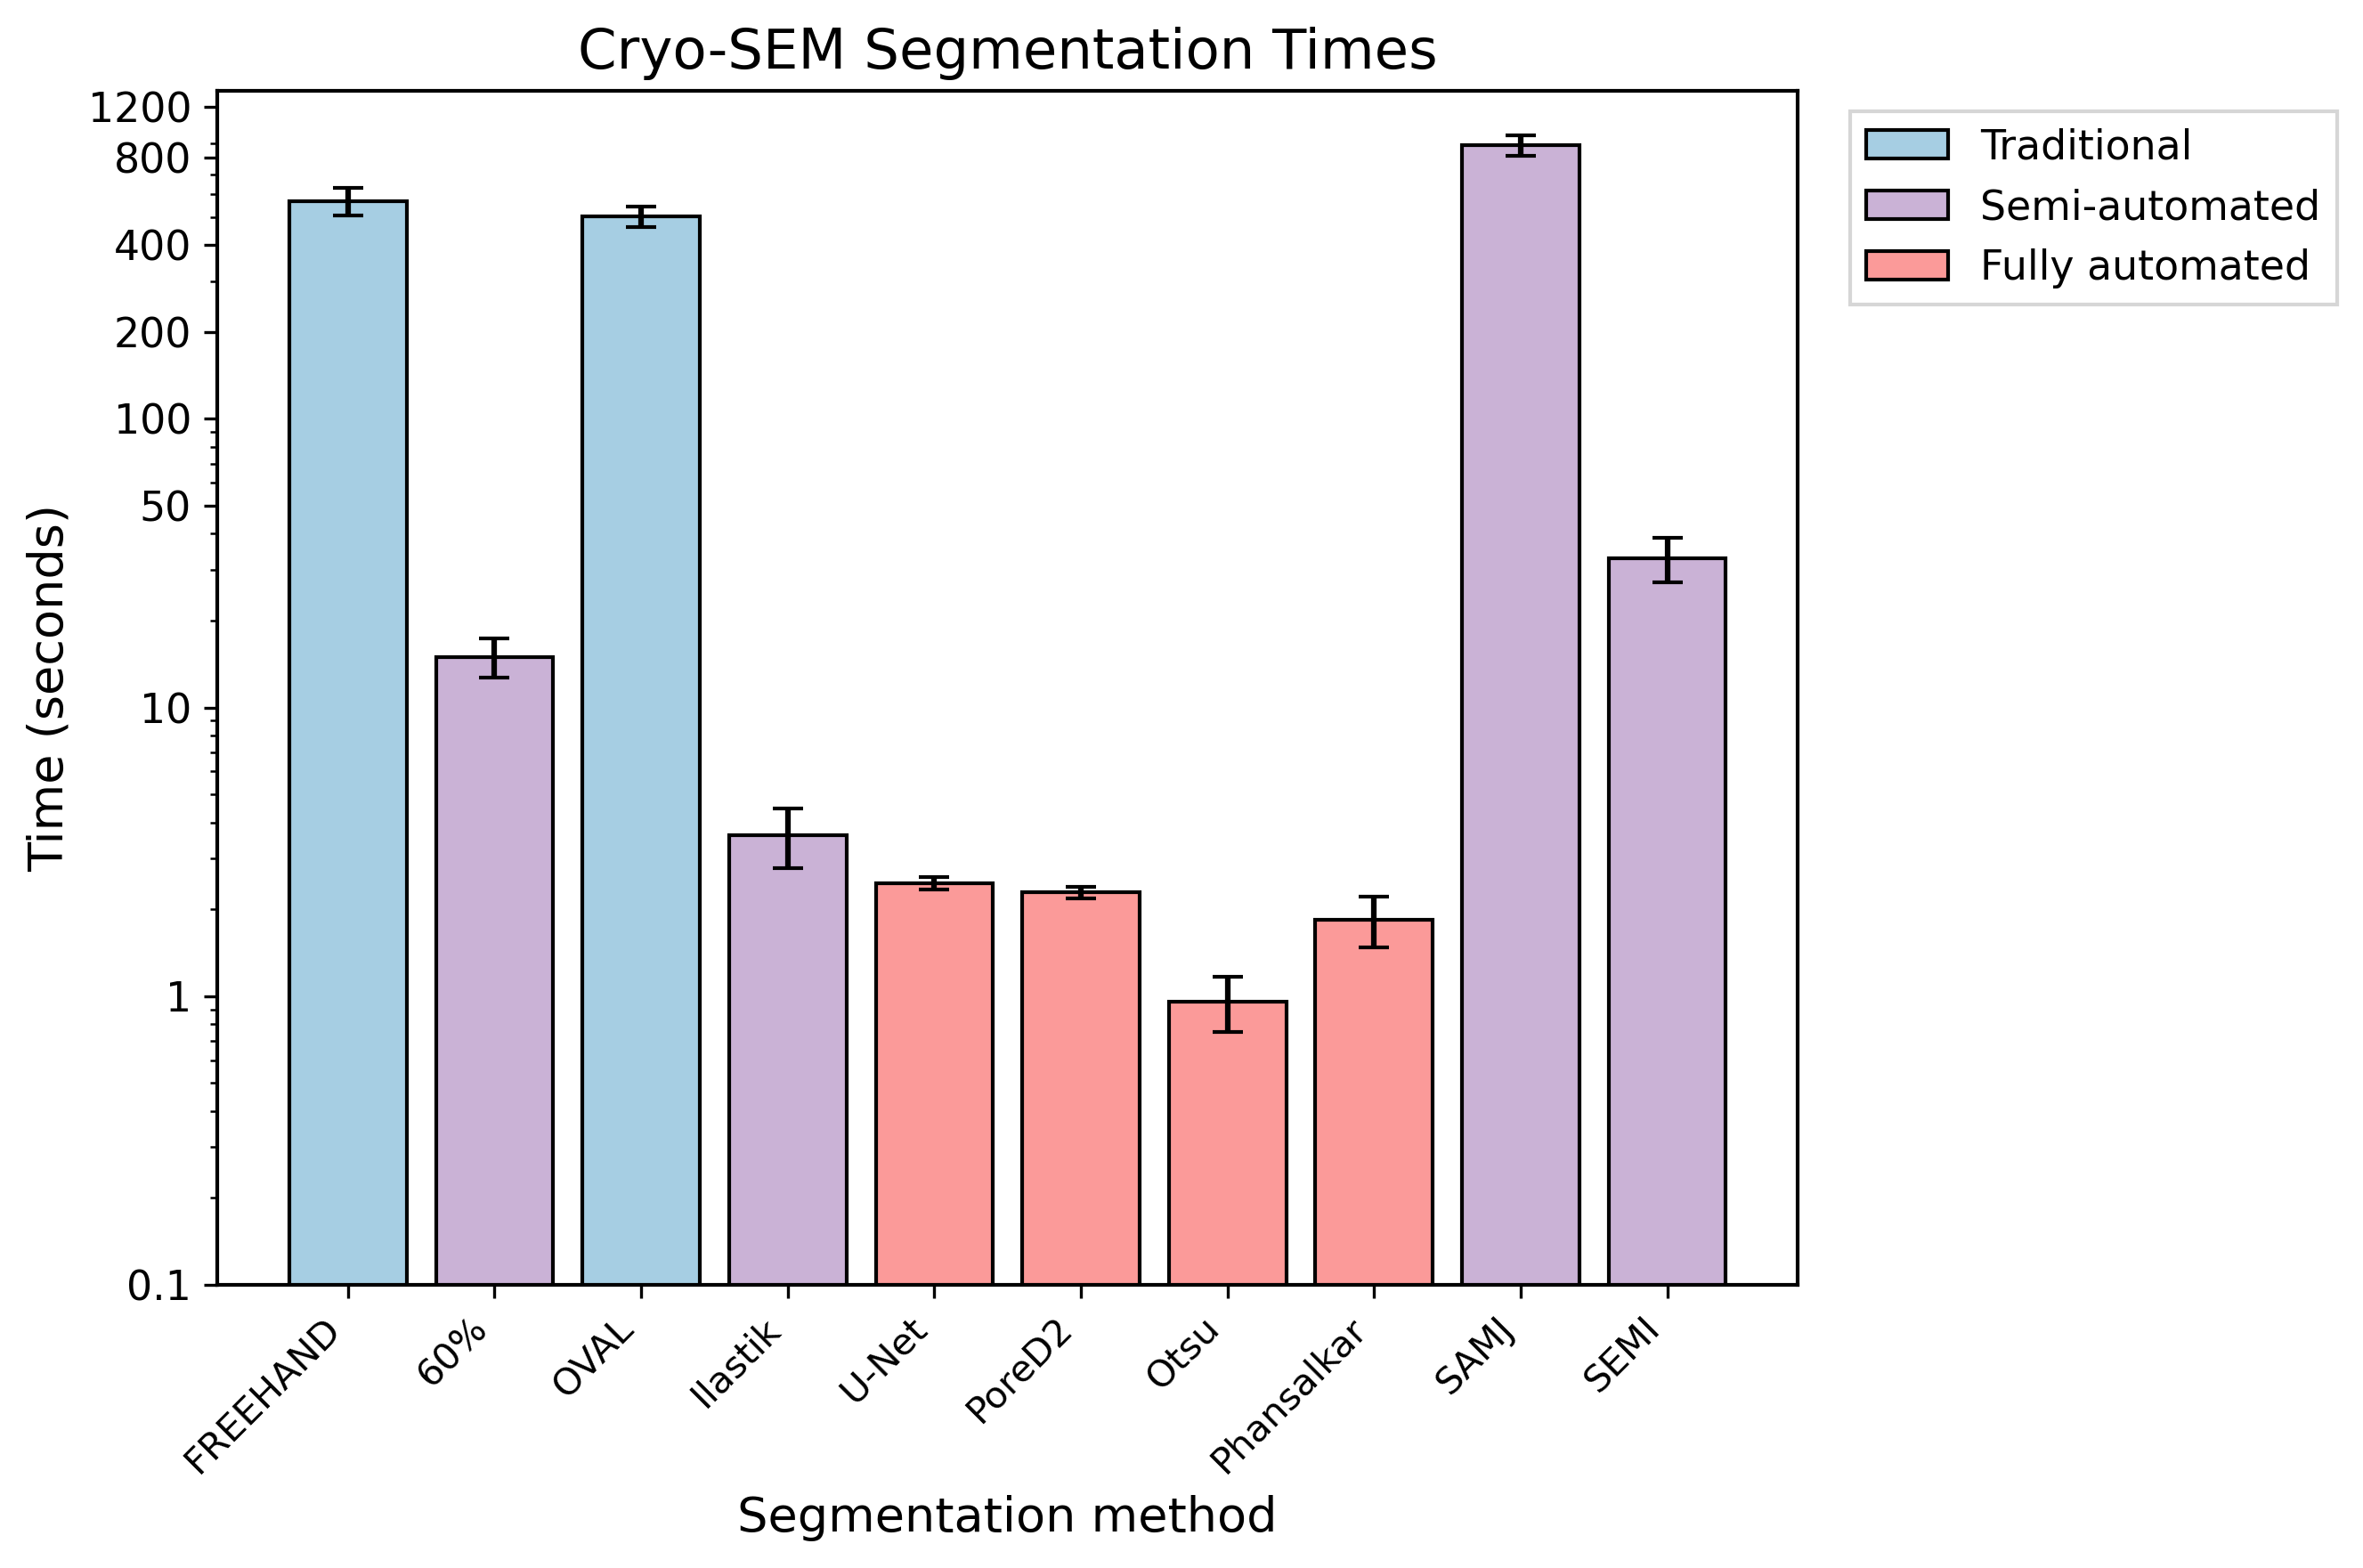

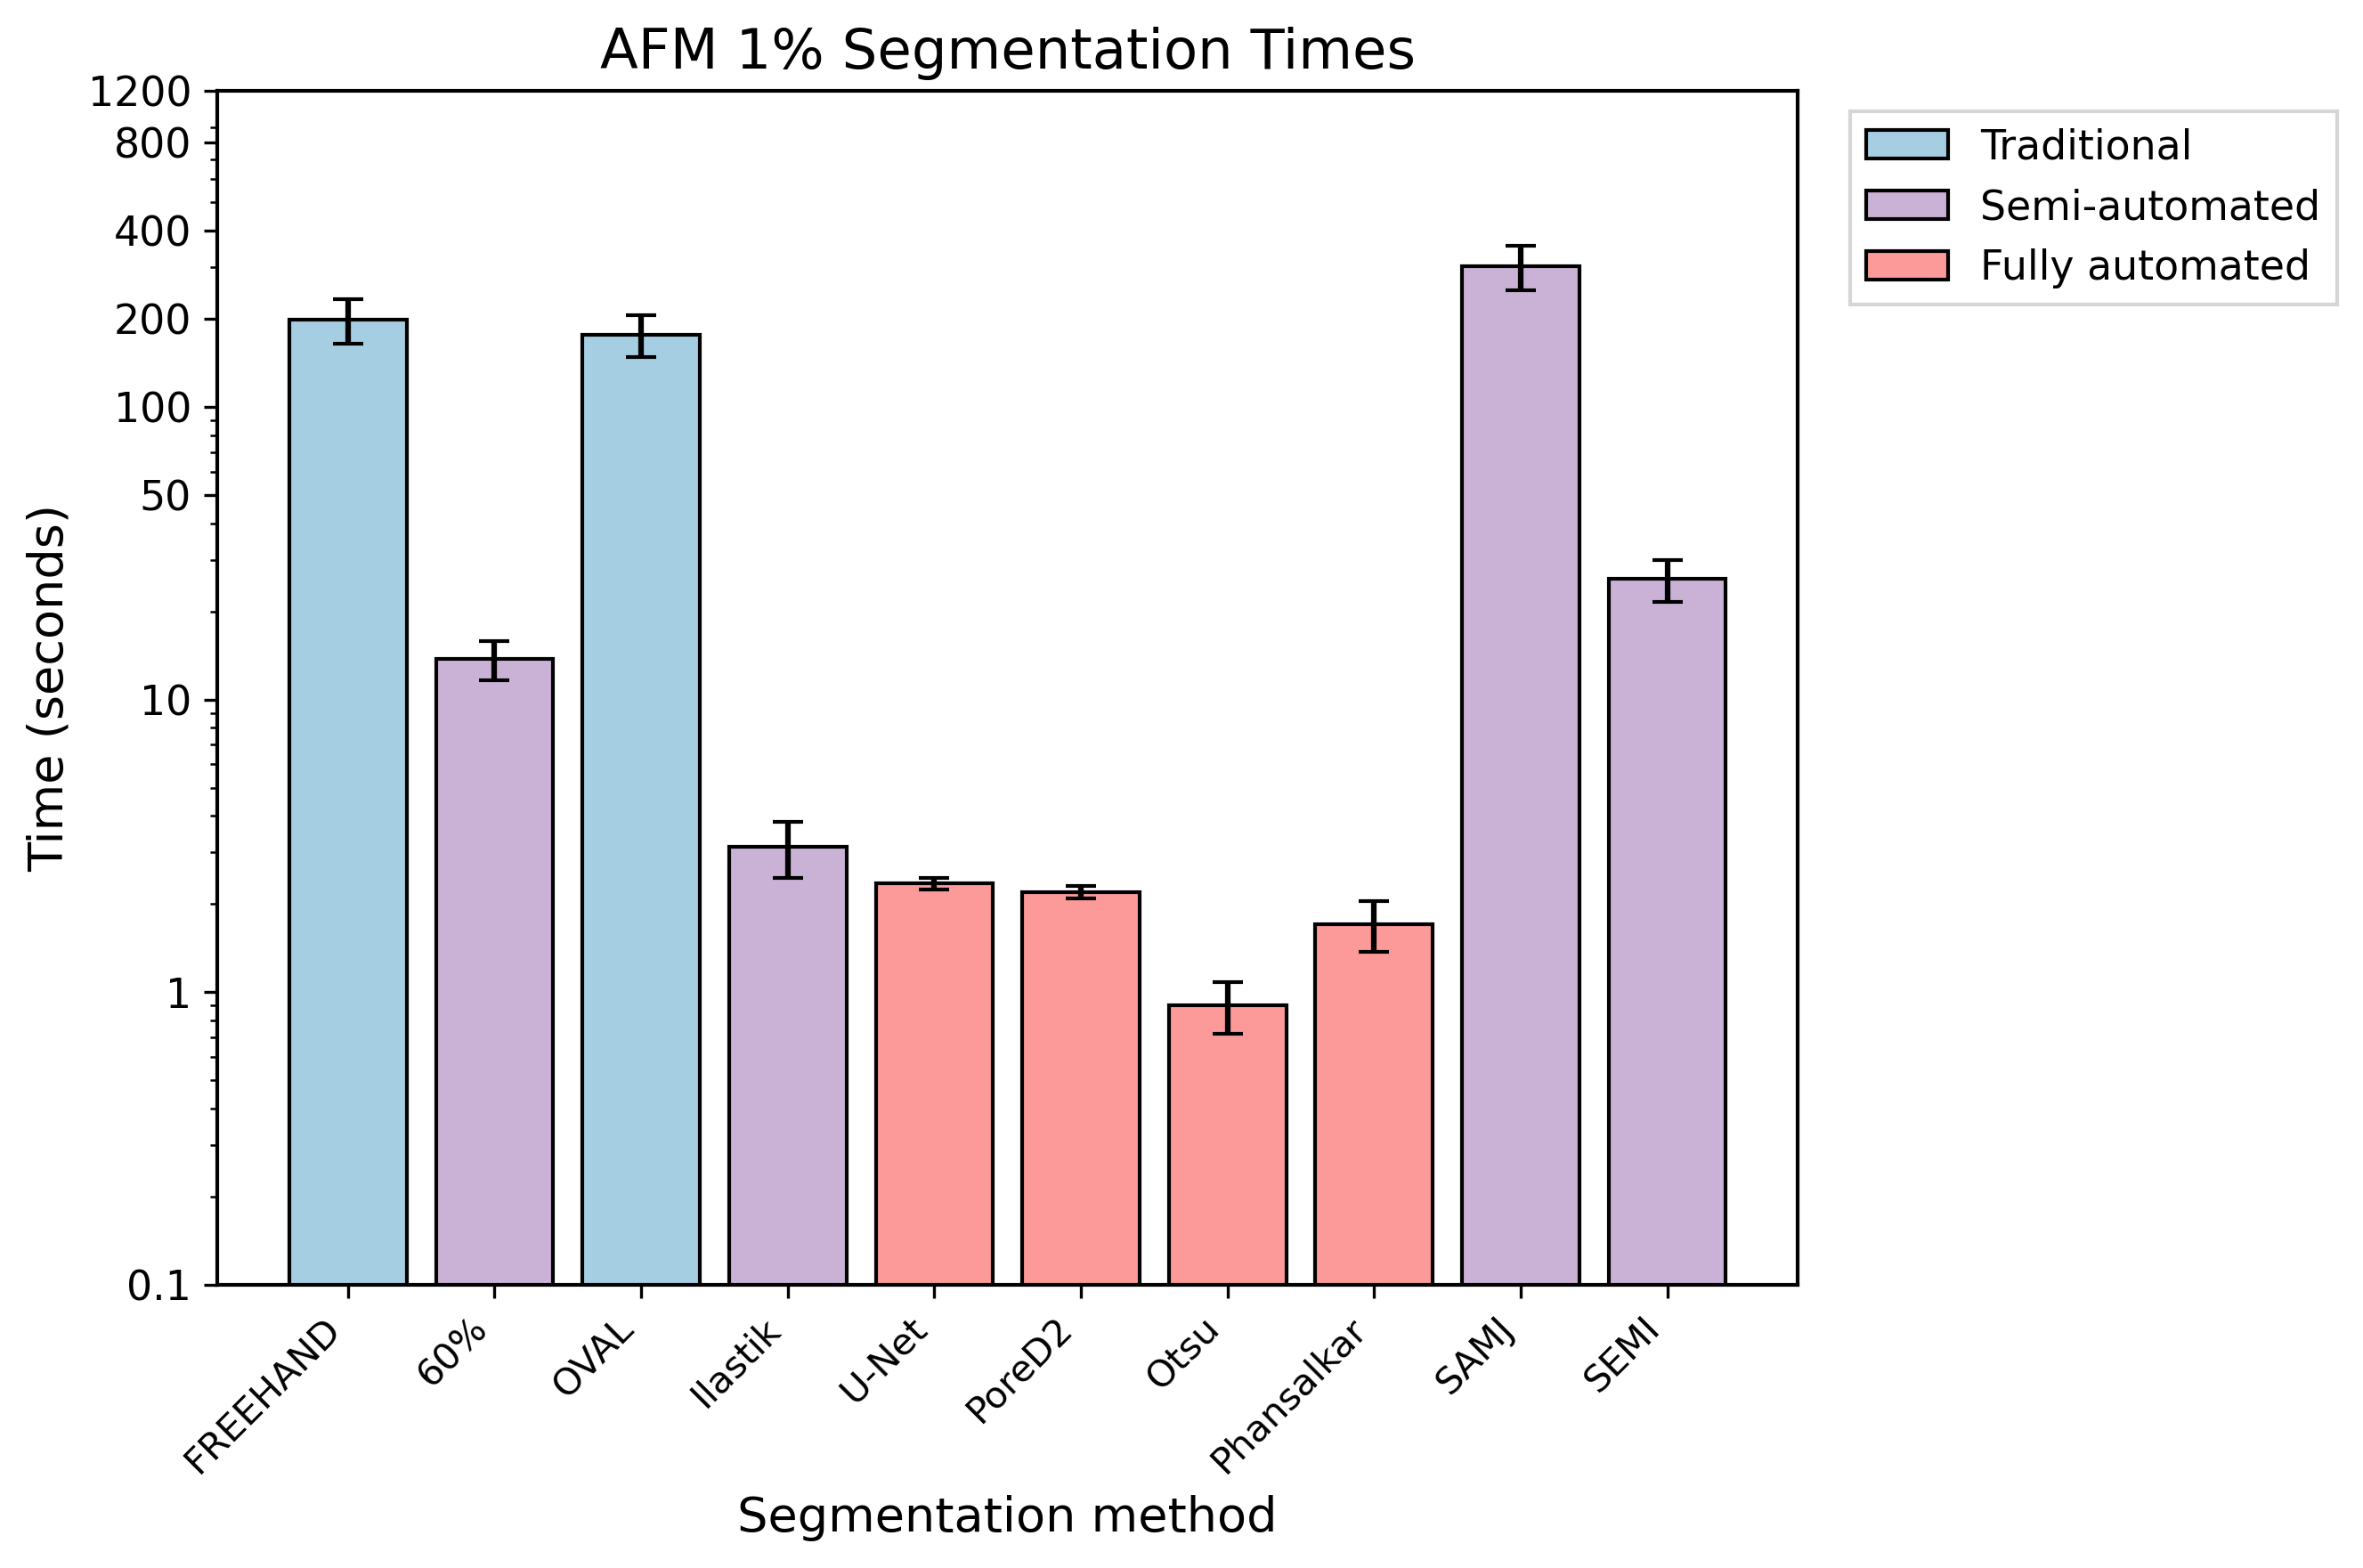

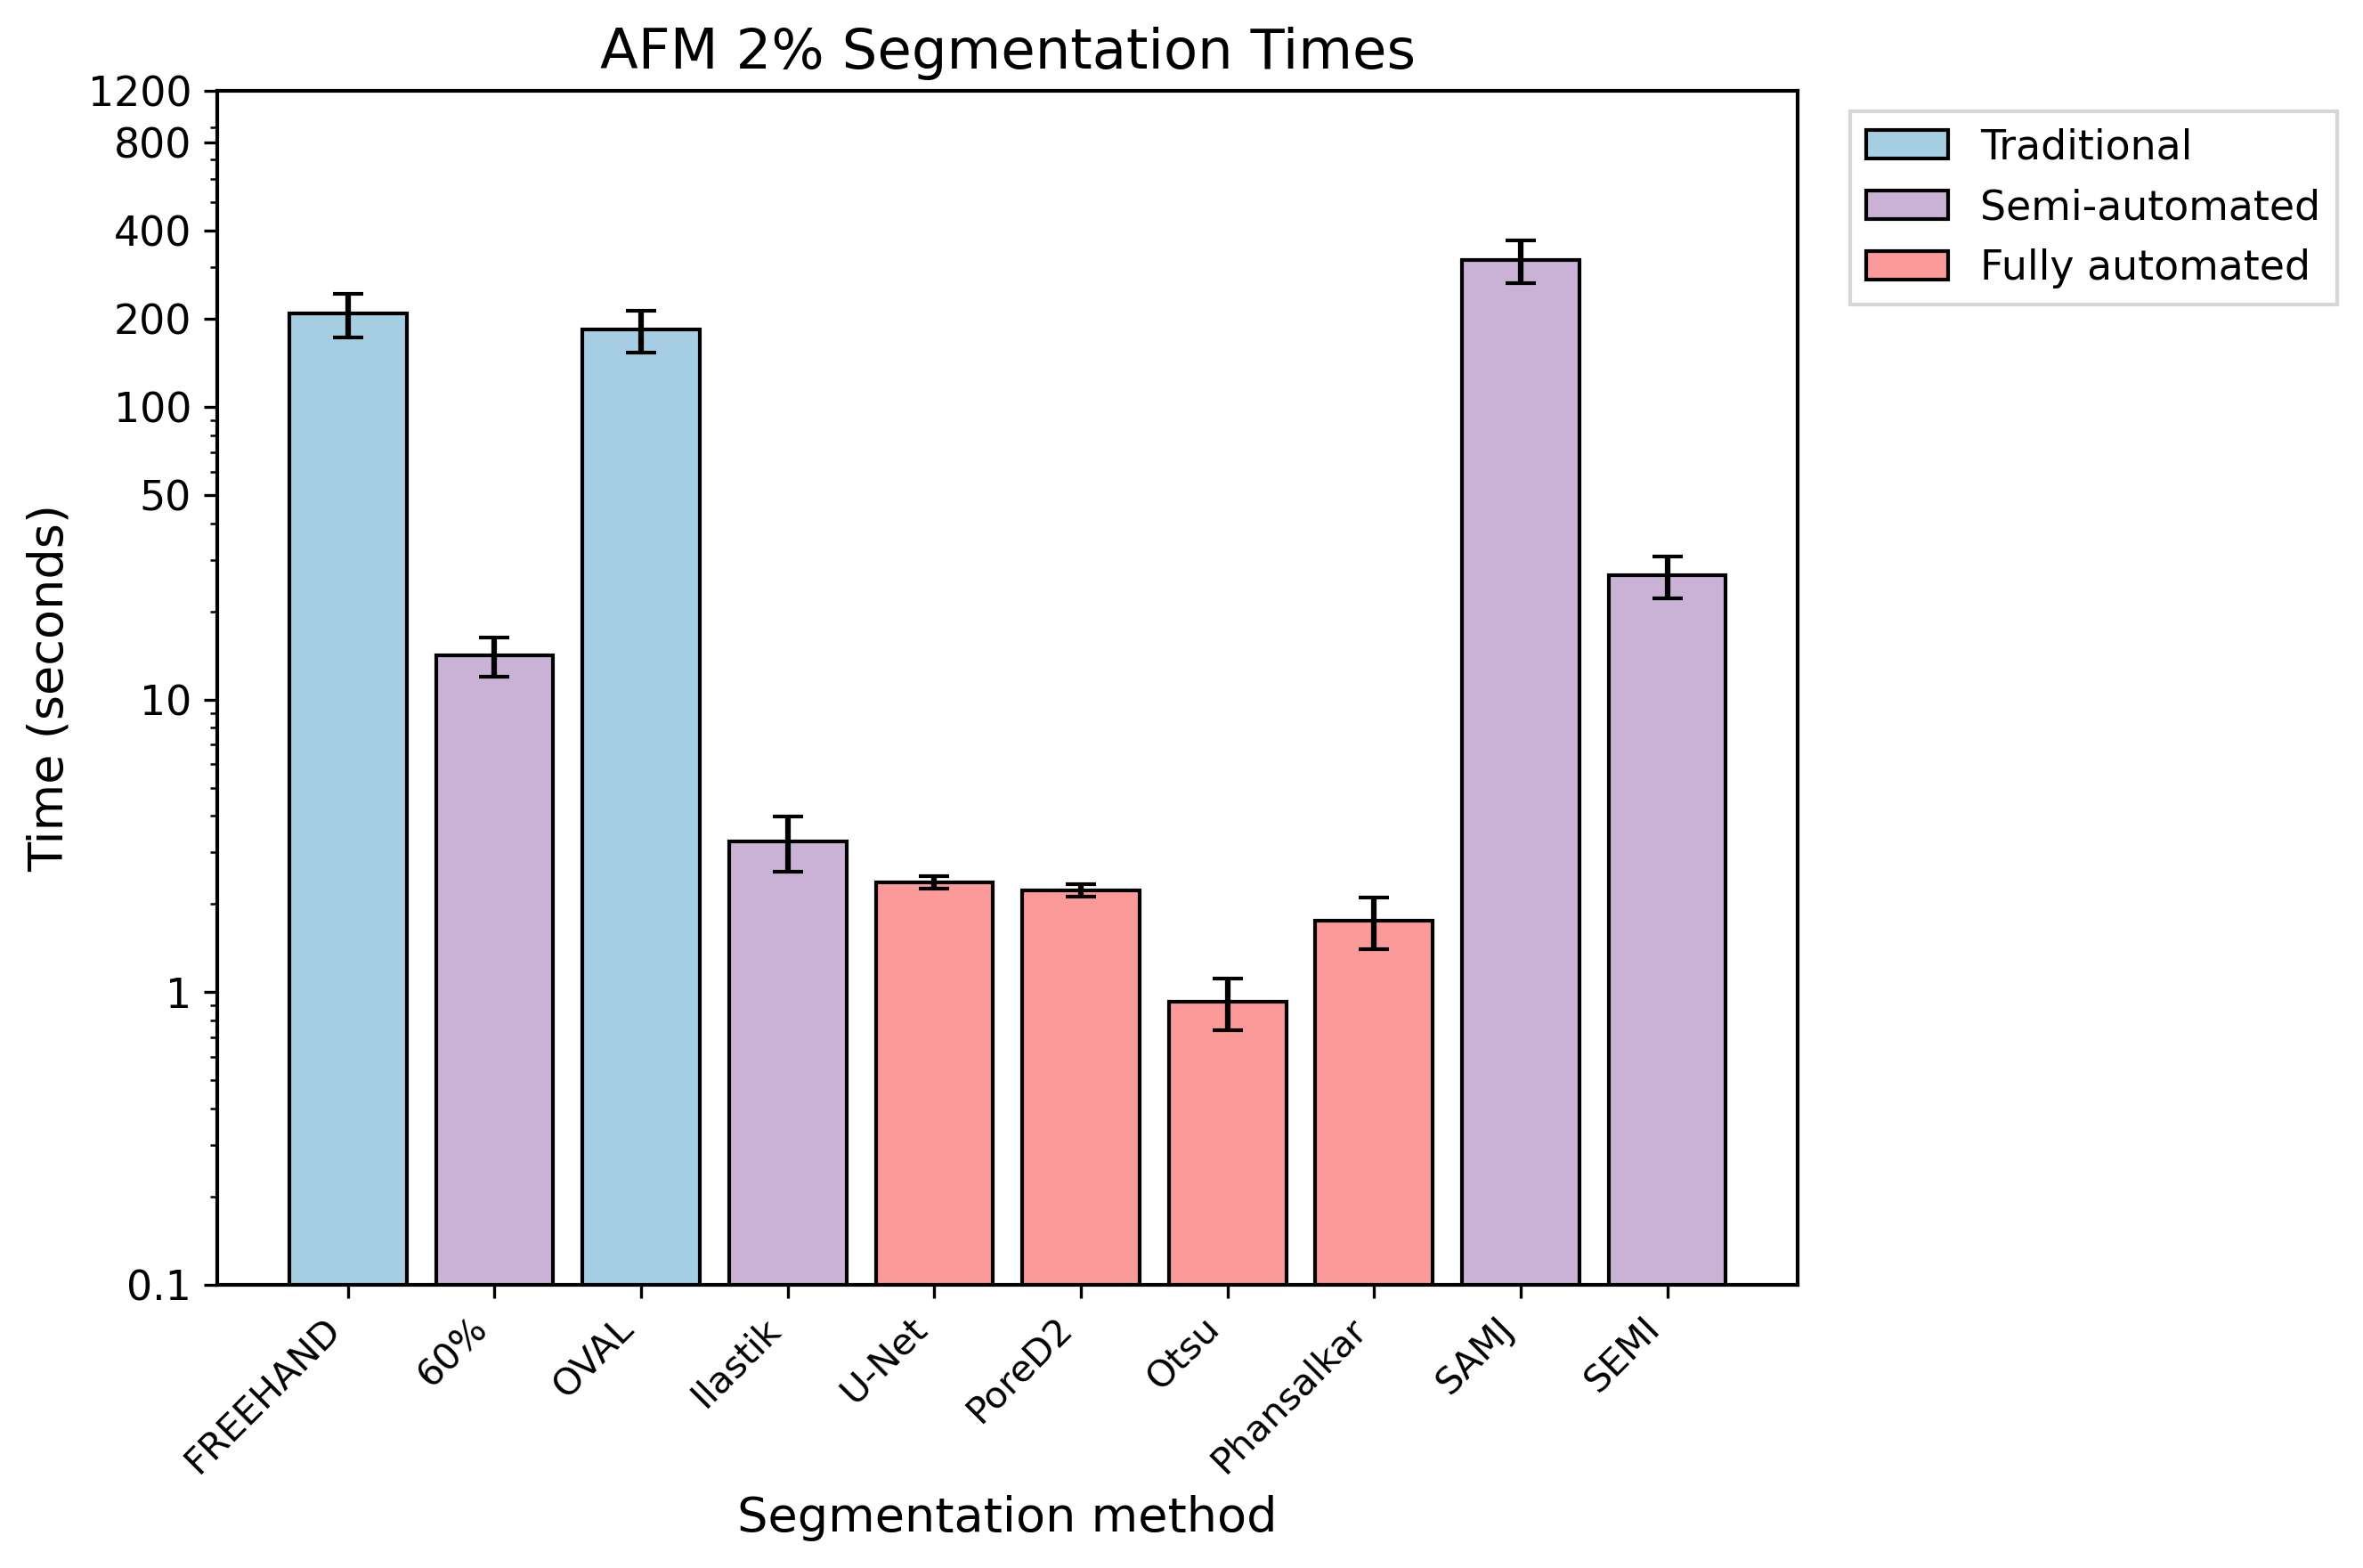

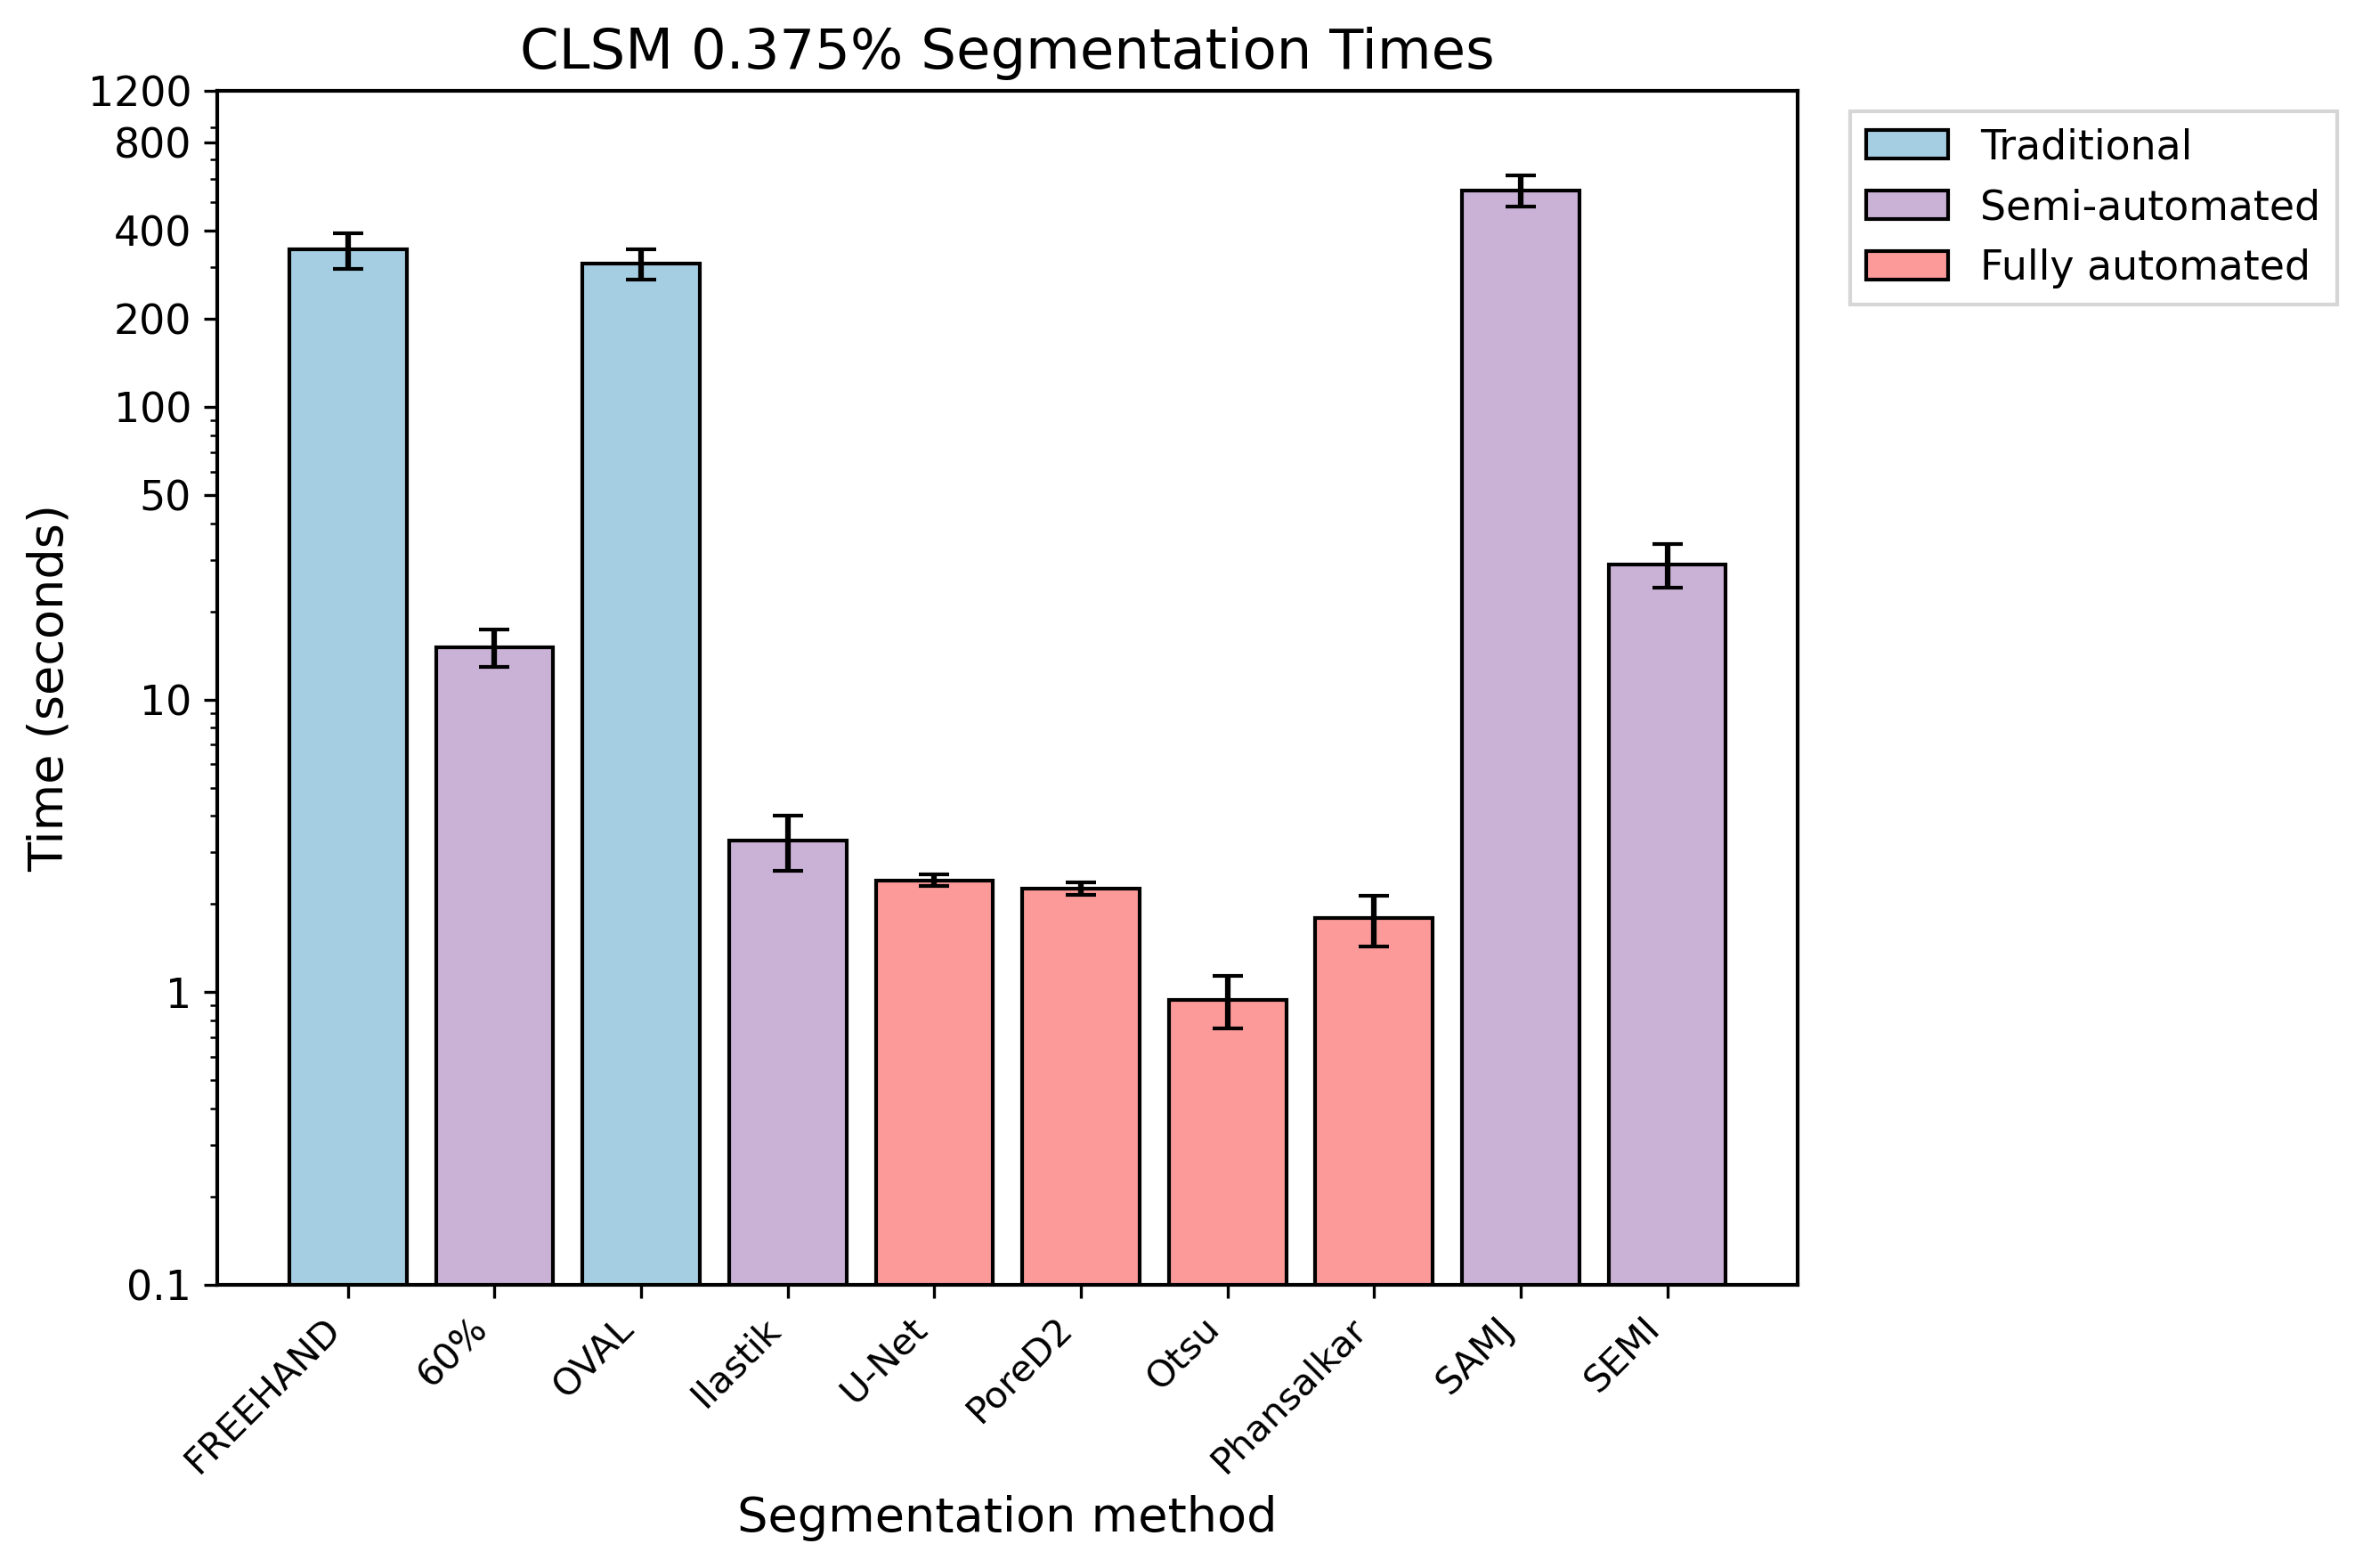

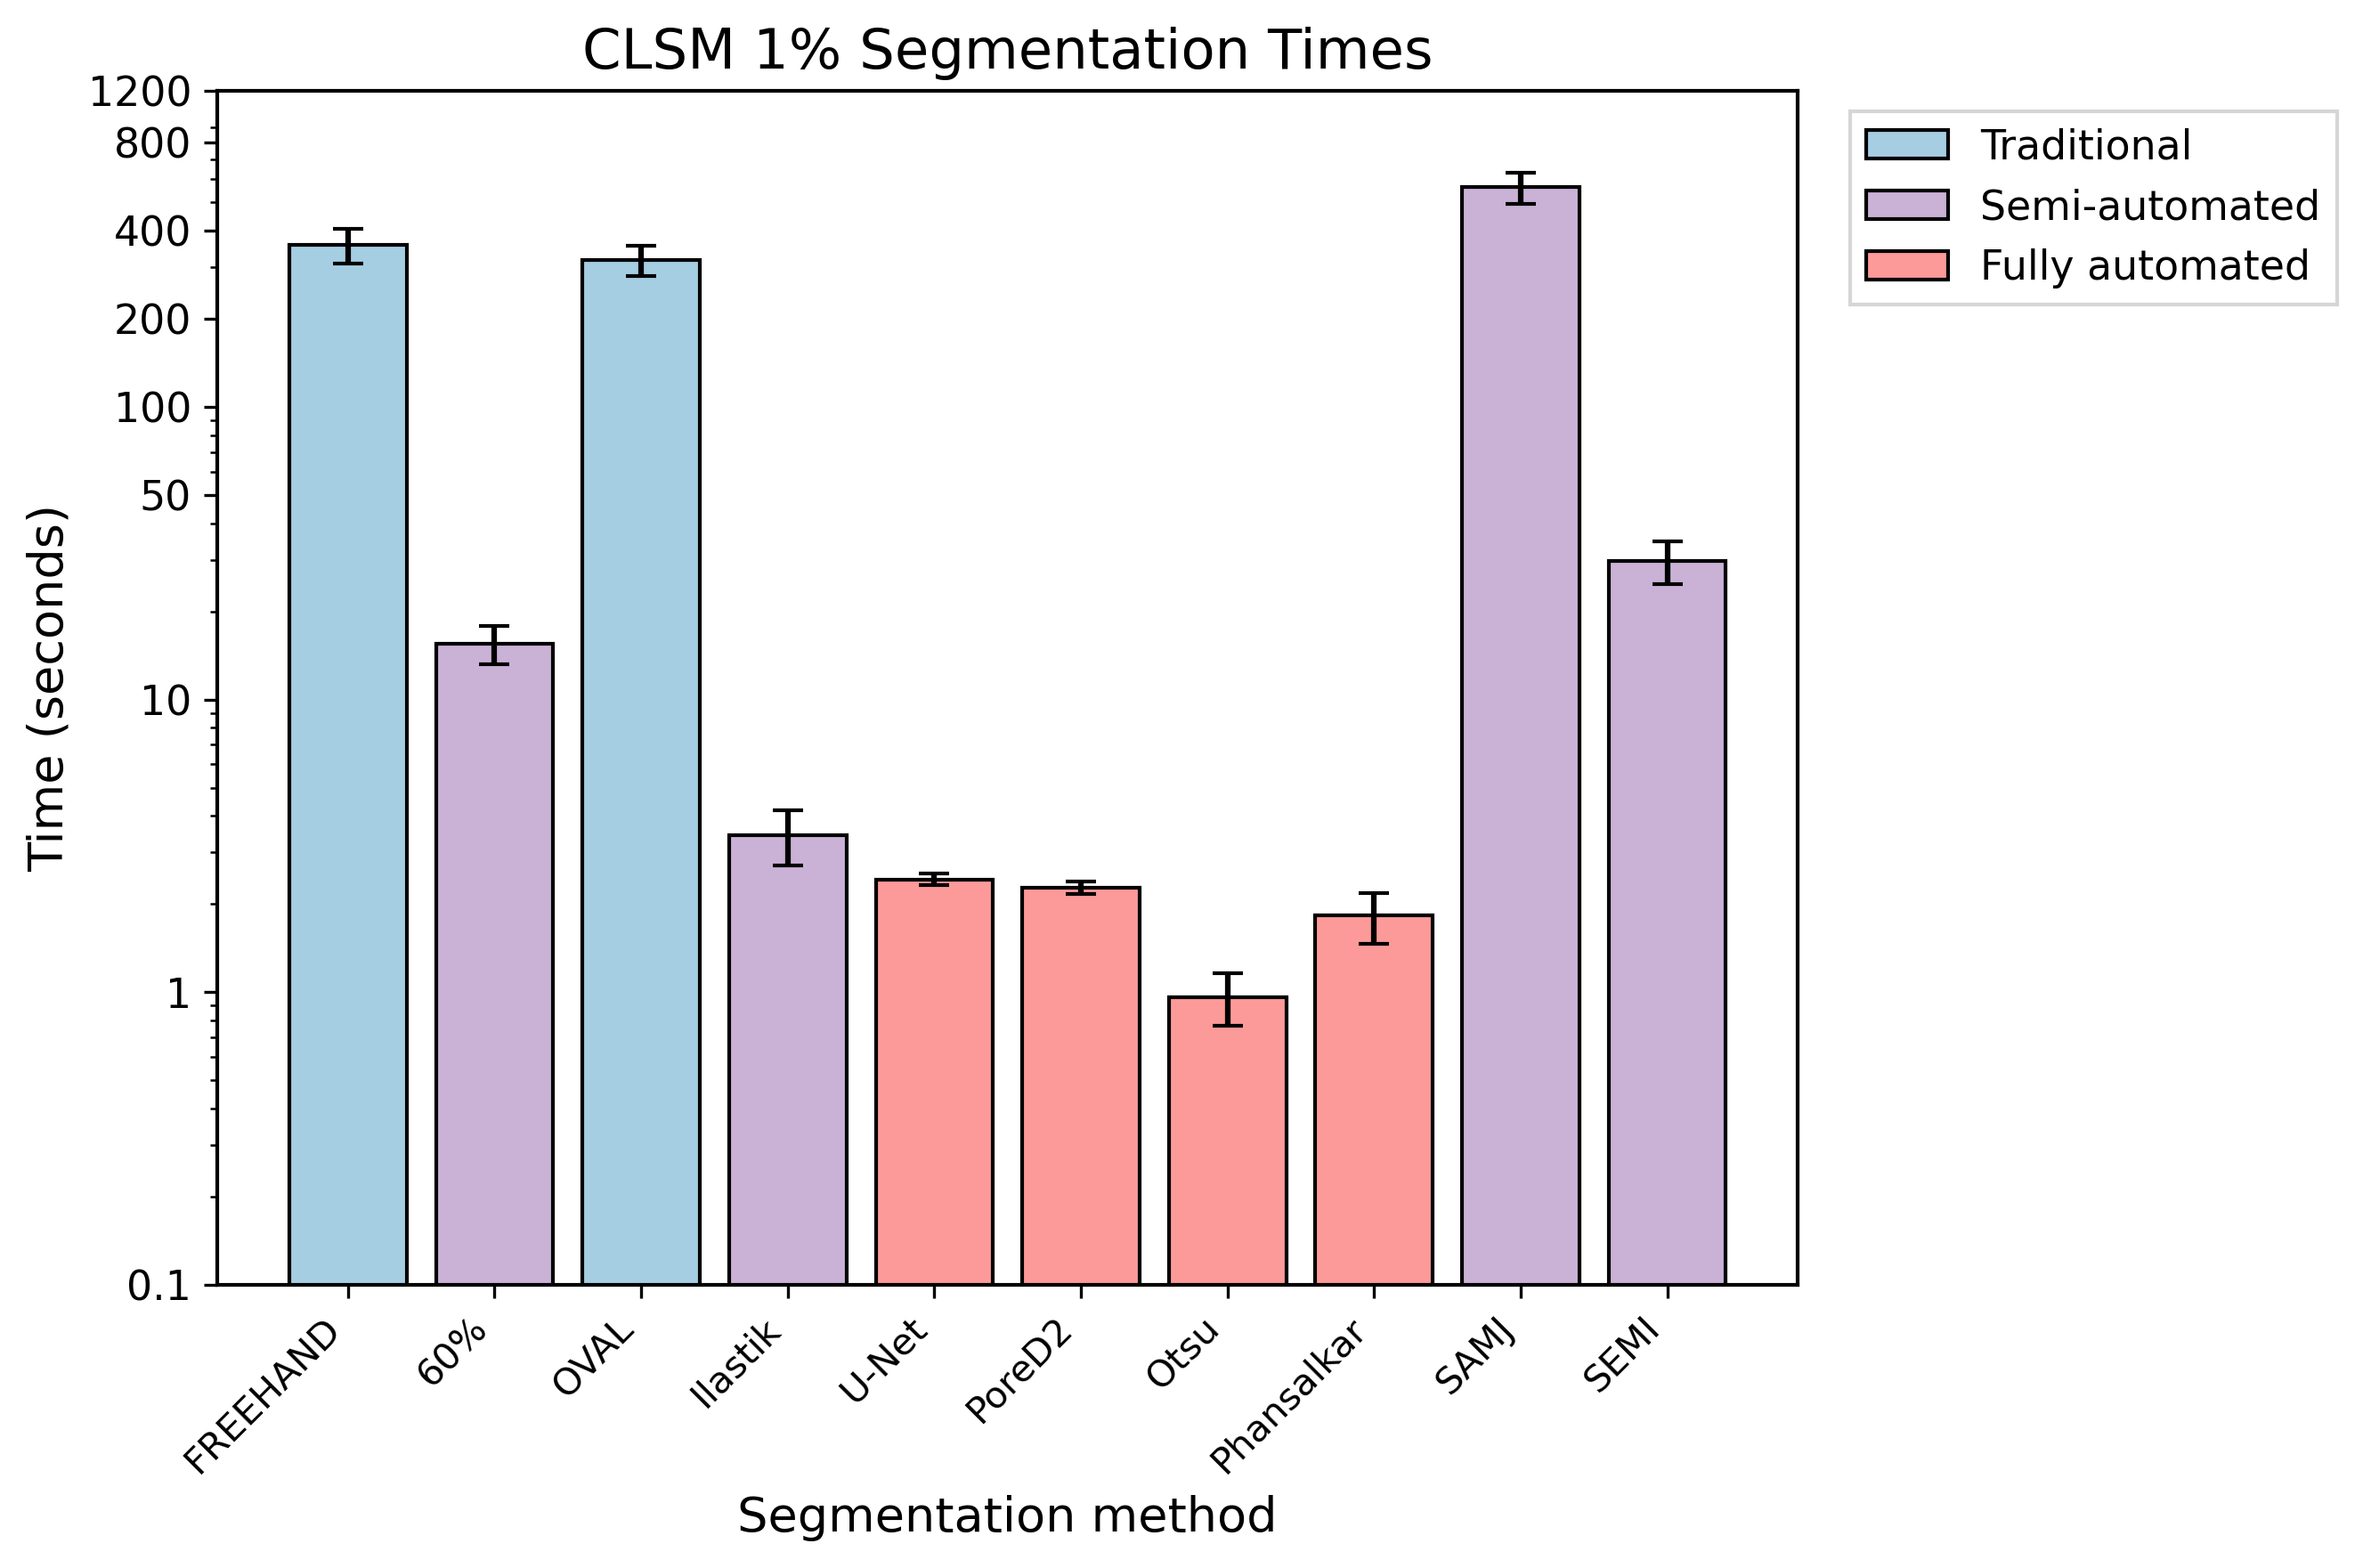

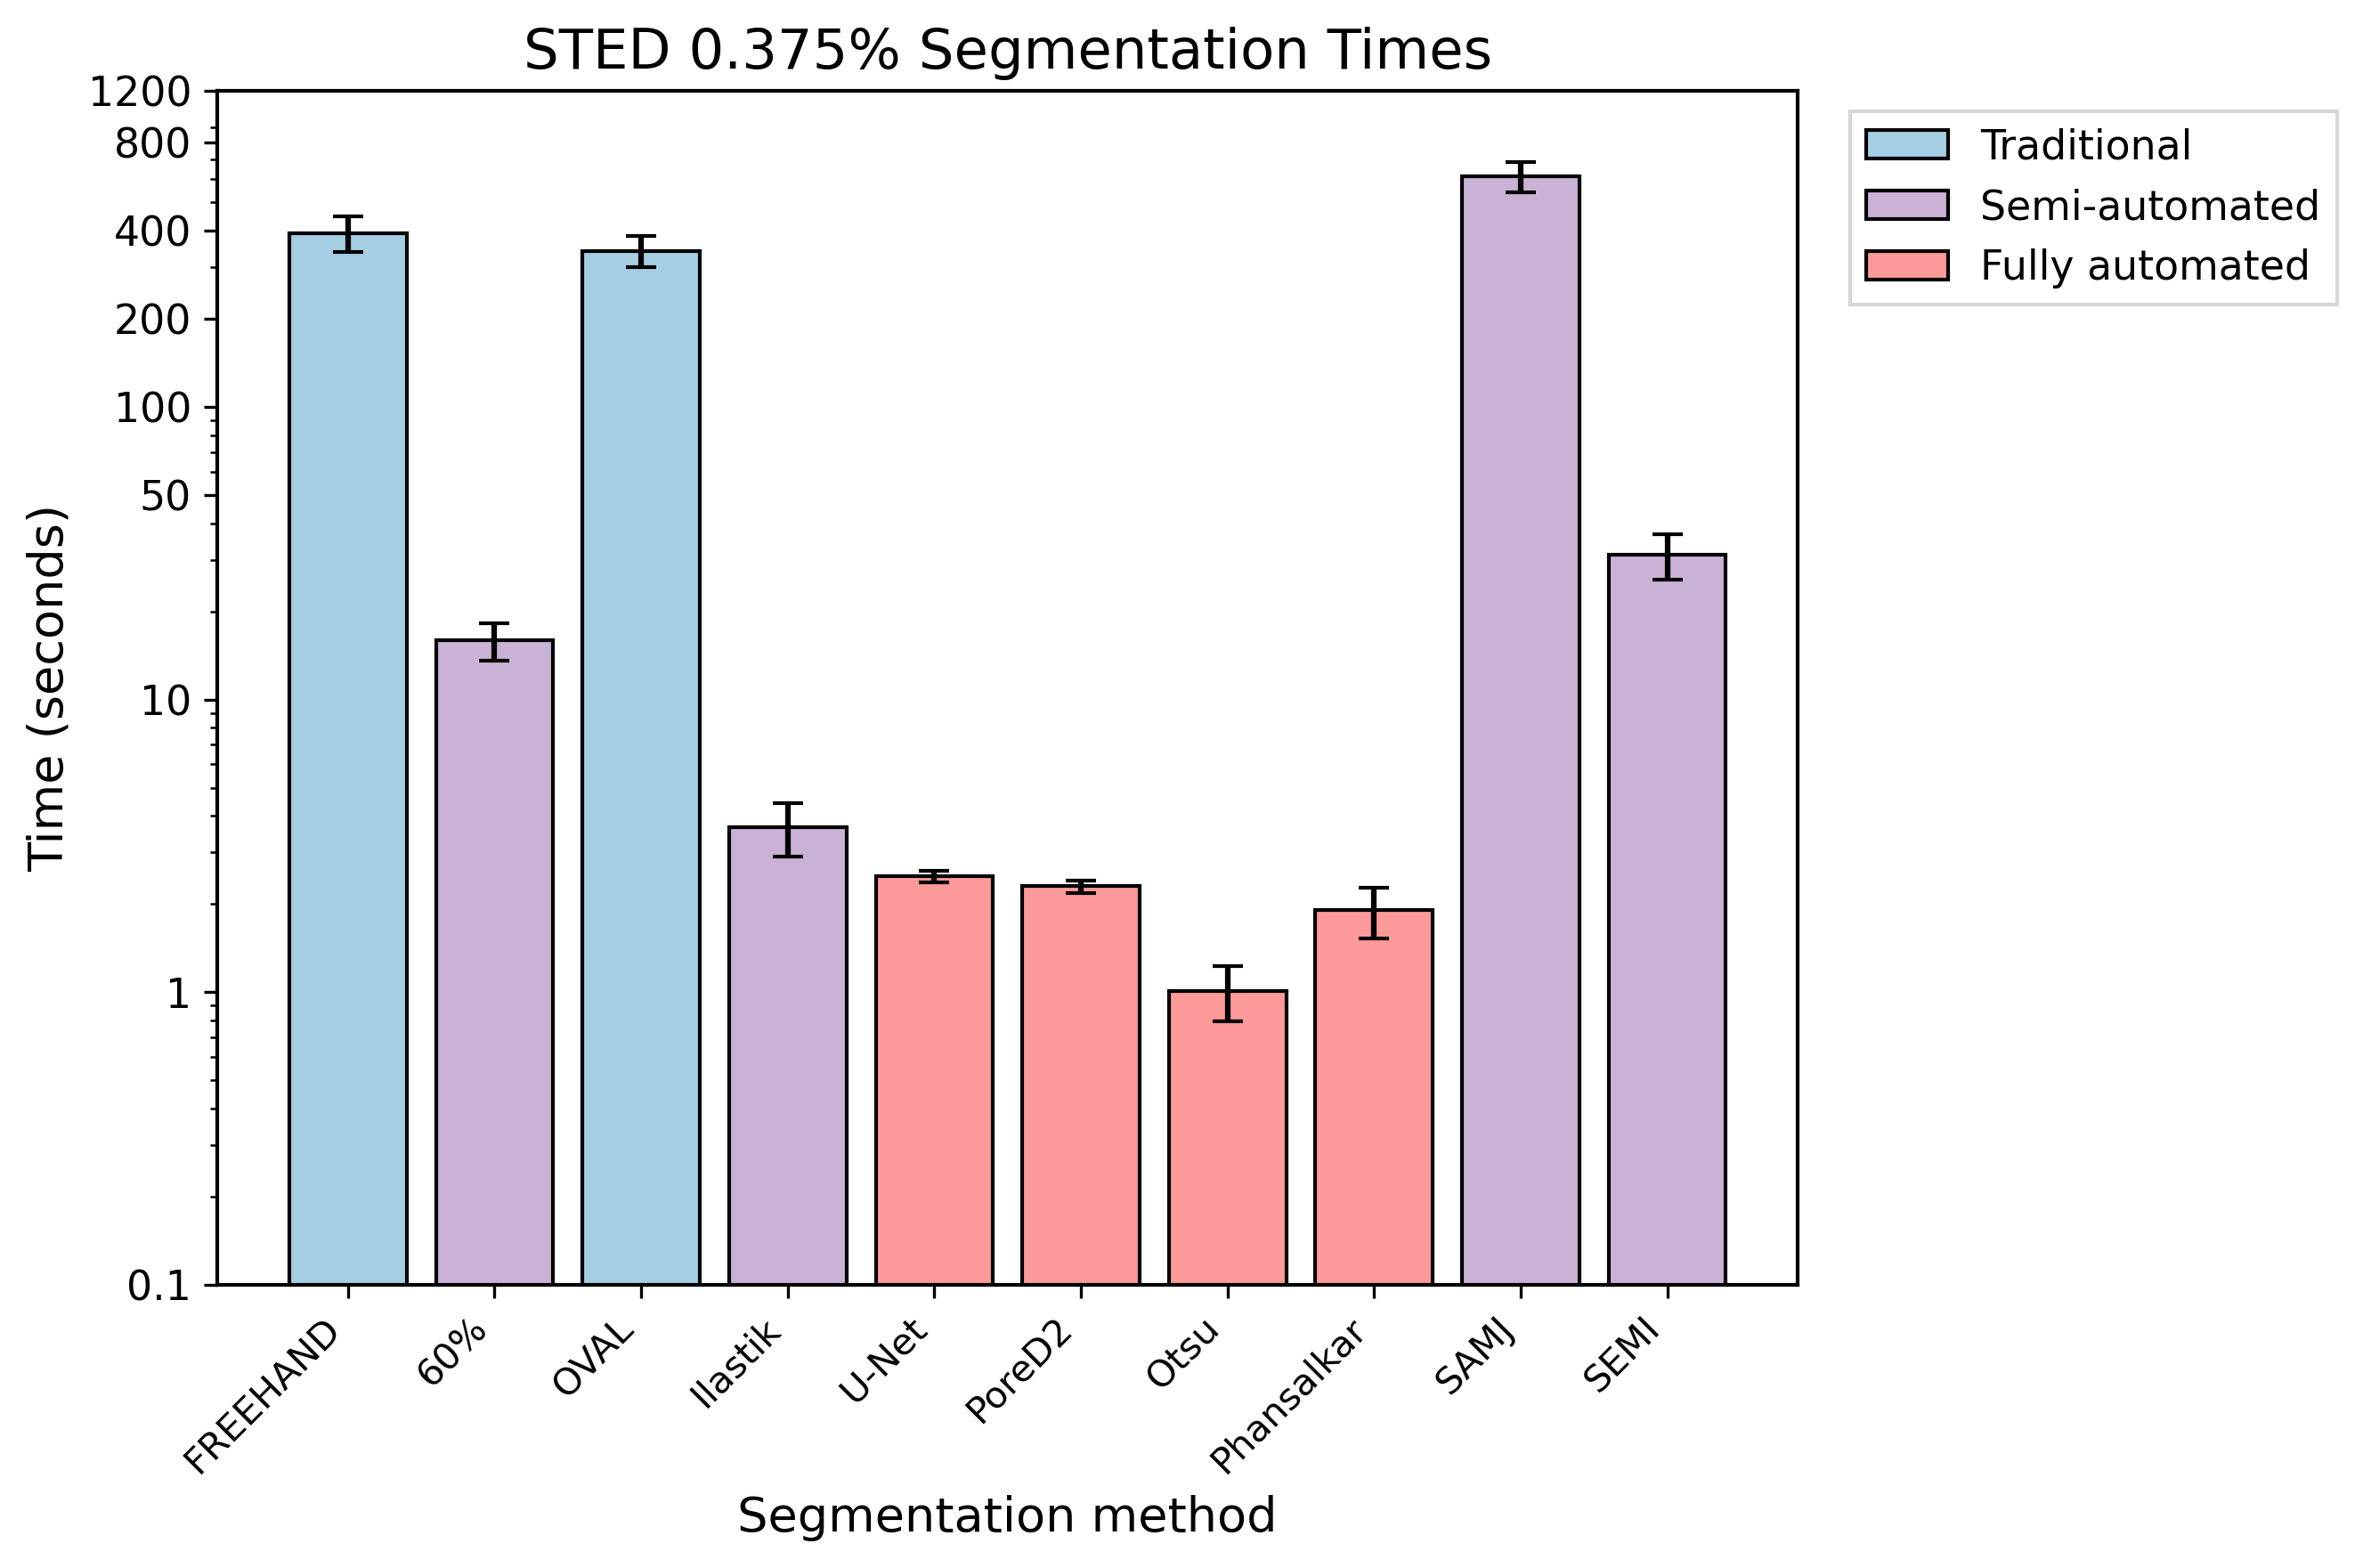

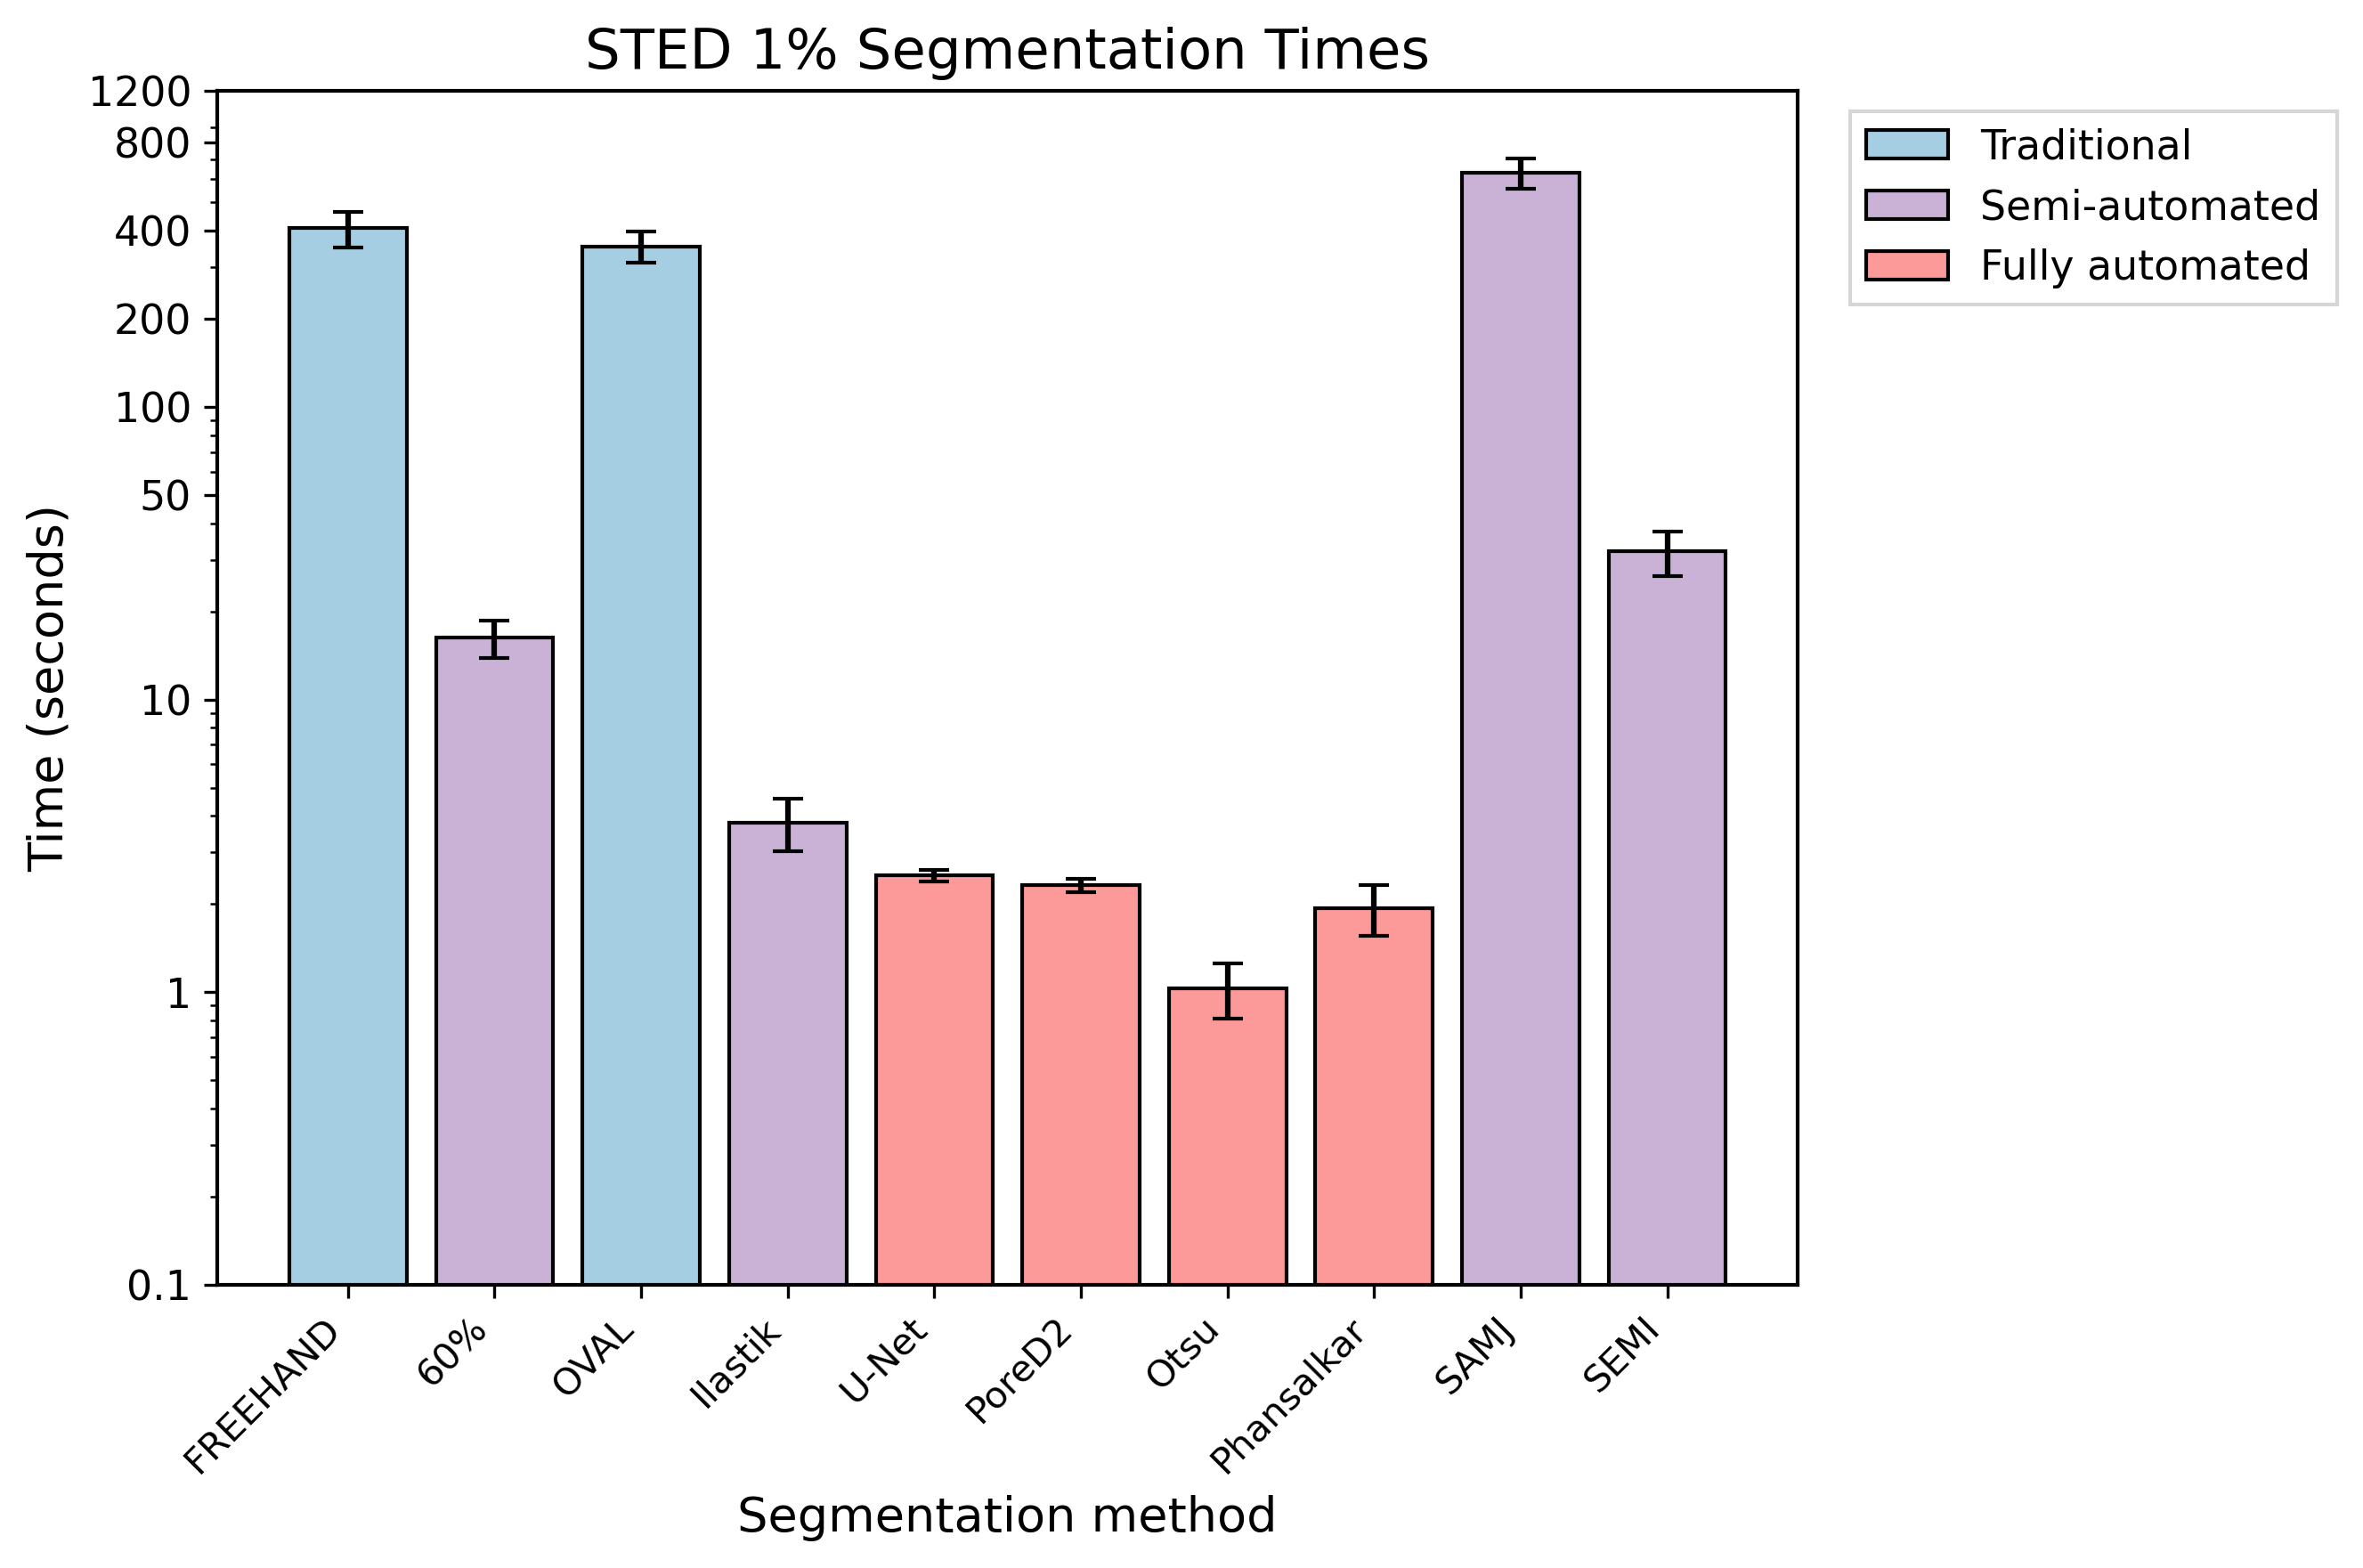

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -------------------------------------------------------
# DATA (means, SDs)
# -------------------------------------------------------
data = {
    "Cryo-SEM": {
        "FREEHAND": (568.442, 63.552),
        "OVAL": (503.118, 41.229),
        "SEMI": (32.914, 5.822),
        "SAMJ": (883.557, 72.441),
        "Ilastik": (3.612, 0.842),
        "60%": (14.982, 2.336),
        "Phansalkar": (1.842, 0.362),
        "Otsu": (0.958, 0.209),
        "PoreD2": (2.287, 0.112),
        "U-Net": (2.466, 0.118),
    },
    "AFM 1%": {
        "FREEHAND": (198.334, 34.551),
        "OVAL": (176.201, 28.882),
        "SEMI": (25.814, 4.223),
        "SAMJ": (302.557, 51.821),
        "Ilastik": (3.144, 0.683),
        "60%": (13.744, 2.114),
        "Phansalkar": (1.712, 0.341),
        "Otsu": (0.904, 0.182),
        "PoreD2": (2.202, 0.109),
        "U-Net": (2.351, 0.111),
    },
    "AFM 2%": {
        "FREEHAND": (207.911, 35.664),
        "OVAL": (183.030, 29.500),
        "SEMI": (26.488, 4.288),
        "SAMJ": (316.991, 53.020),
        "Ilastik": (3.284, 0.699),
        "60%": (14.118, 2.182),
        "Phansalkar": (1.752, 0.349),
        "Otsu": (0.927, 0.188),
        "PoreD2": (2.224, 0.110),
        "U-Net": (2.372, 0.112),
    },
    "CLSM 0.375%": {
        "FREEHAND": (344.552, 47.910),
        "OVAL": (308.331, 37.220),
        "SEMI": (28.991, 4.902),
        "SAMJ": (548.772, 67.442),
        "Ilastik": (3.302, 0.713),
        "60%": (15.117, 2.225),
        "Phansalkar": (1.786, 0.351),
        "Otsu": (0.944, 0.194),
        "PoreD2": (2.254, 0.111),
        "U-Net": (2.412, 0.113),
    },
    "CLSM 1%": {
        "FREEHAND": (356.882, 49.210),
        "OVAL": (317.004, 38.004),
        "SEMI": (29.744, 5.020),
        "SAMJ": (561.991, 69.120),
        "Ilastik": (3.442, 0.728),
        "60%": (15.488, 2.280),
        "Phansalkar": (1.824, 0.358),
        "Otsu": (0.964, 0.197),
        "PoreD2": (2.271, 0.112),
        "U-Net": (2.429, 0.114),
    },
    "STED 0.375%": {
        "FREEHAND": (392.441, 55.221),
        "OVAL": (341.115, 41.992),
        "SEMI": (31.114, 5.442),
        "SAMJ": (612.228, 73.550),
        "Ilastik": (3.665, 0.752),
        "60%": (15.887, 2.341),
        "Phansalkar": (1.904, 0.374),
        "Otsu": (1.011, 0.214),
        "PoreD2": (2.299, 0.114),
        "U-Net": (2.487, 0.116),
    },
    "STED 1%": {
        "FREEHAND": (406.662, 56.880),
        "OVAL": (353.223, 43.117),
        "SEMI": (32.001, 5.550),
        "SAMJ": (630.554, 75.882),
        "Ilastik": (3.802, 0.767),
        "60%": (16.224, 2.395),
        "Phansalkar": (1.941, 0.381),
        "Otsu": (1.033, 0.219),
        "PoreD2": (2.317, 0.115),
        "U-Net": (2.503, 0.117),
    },
}

# -------------------------------------------------------
# CATEGORY COLORS
# -------------------------------------------------------
categories = {
    "FREEHAND": "Traditional",
    "OVAL": "Traditional",
    "SEMI": "Semi-automated",
    "SAMJ": "Semi-automated",
    "Ilastik": "Semi-automated",
    "60%": "Semi-automated",
    "Phansalkar": "Fully-automated",
    "Otsu": "Fully-automated",
    "PoreD2": "Fully-automated",
    "U-Net": "Fully-automated",
}

category_colors = {
    "Traditional": "#a6cee3",
    "Semi-automated": "#cab2d6",
    "Fully-automated": "#fb9a99",
}

method_order = [
    "FREEHAND", "60%", "OVAL", "Ilastik",
    "U-Net", "PoreD2", "Otsu", "Phansalkar",
    "SAMJ", "SEMI"
]

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
})

# Clean, spaced-out log ticks
yticks = [0.1, 1, 10, 50, 100, 200, 400, 800, 1200]

legend_handles = [
    Patch(facecolor=category_colors["Traditional"], edgecolor="black", label="Traditional"),
    Patch(facecolor=category_colors["Semi-automated"], edgecolor="black", label="Semi-automated"),
    Patch(facecolor=category_colors["Fully-automated"], edgecolor="black", label="Fully automated"),
]

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------
for modality, results in data.items():

    means = [results[m][0] for m in method_order]
    sds   = [results[m][1] for m in method_order]
    x = np.arange(len(method_order))
    colors = [category_colors[categories[m]] for m in method_order]

    fig, ax = plt.subplots(figsize=(9, 6))

    # bar chart
    ax.bar(
        x, means,
        yerr=sds,
        capsize=4,
        color=colors,
        edgecolor="black",
        linewidth=1,
    )

    # log-scale y-axis
    ax.set_yscale("log")
    ax.set_yticks(yticks)
    ax.get_yaxis().set_major_formatter(
        plt.FuncFormatter(lambda v,_: f"{v:g}")
    )

    # axis labels
    ax.set_xlabel("Segmentation method")
    ax.set_ylabel("Time (seconds)")

    # *** UPDATED TITLE FORMAT ***
    ax.set_title(f"{modality} Segmentation Times")

    # x labels
    ax.set_xticks(x)
    ax.set_xticklabels(method_order, rotation=45, ha="right")

    # full outline around graph
    for spine in ax.spines.values():
        spine.set_linewidth(1)
        spine.set_visible(True)

    # legend outside top-right
    ax.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        frameon=True,
        fancybox=False,
    )

    plt.tight_layout()
    plt.show()

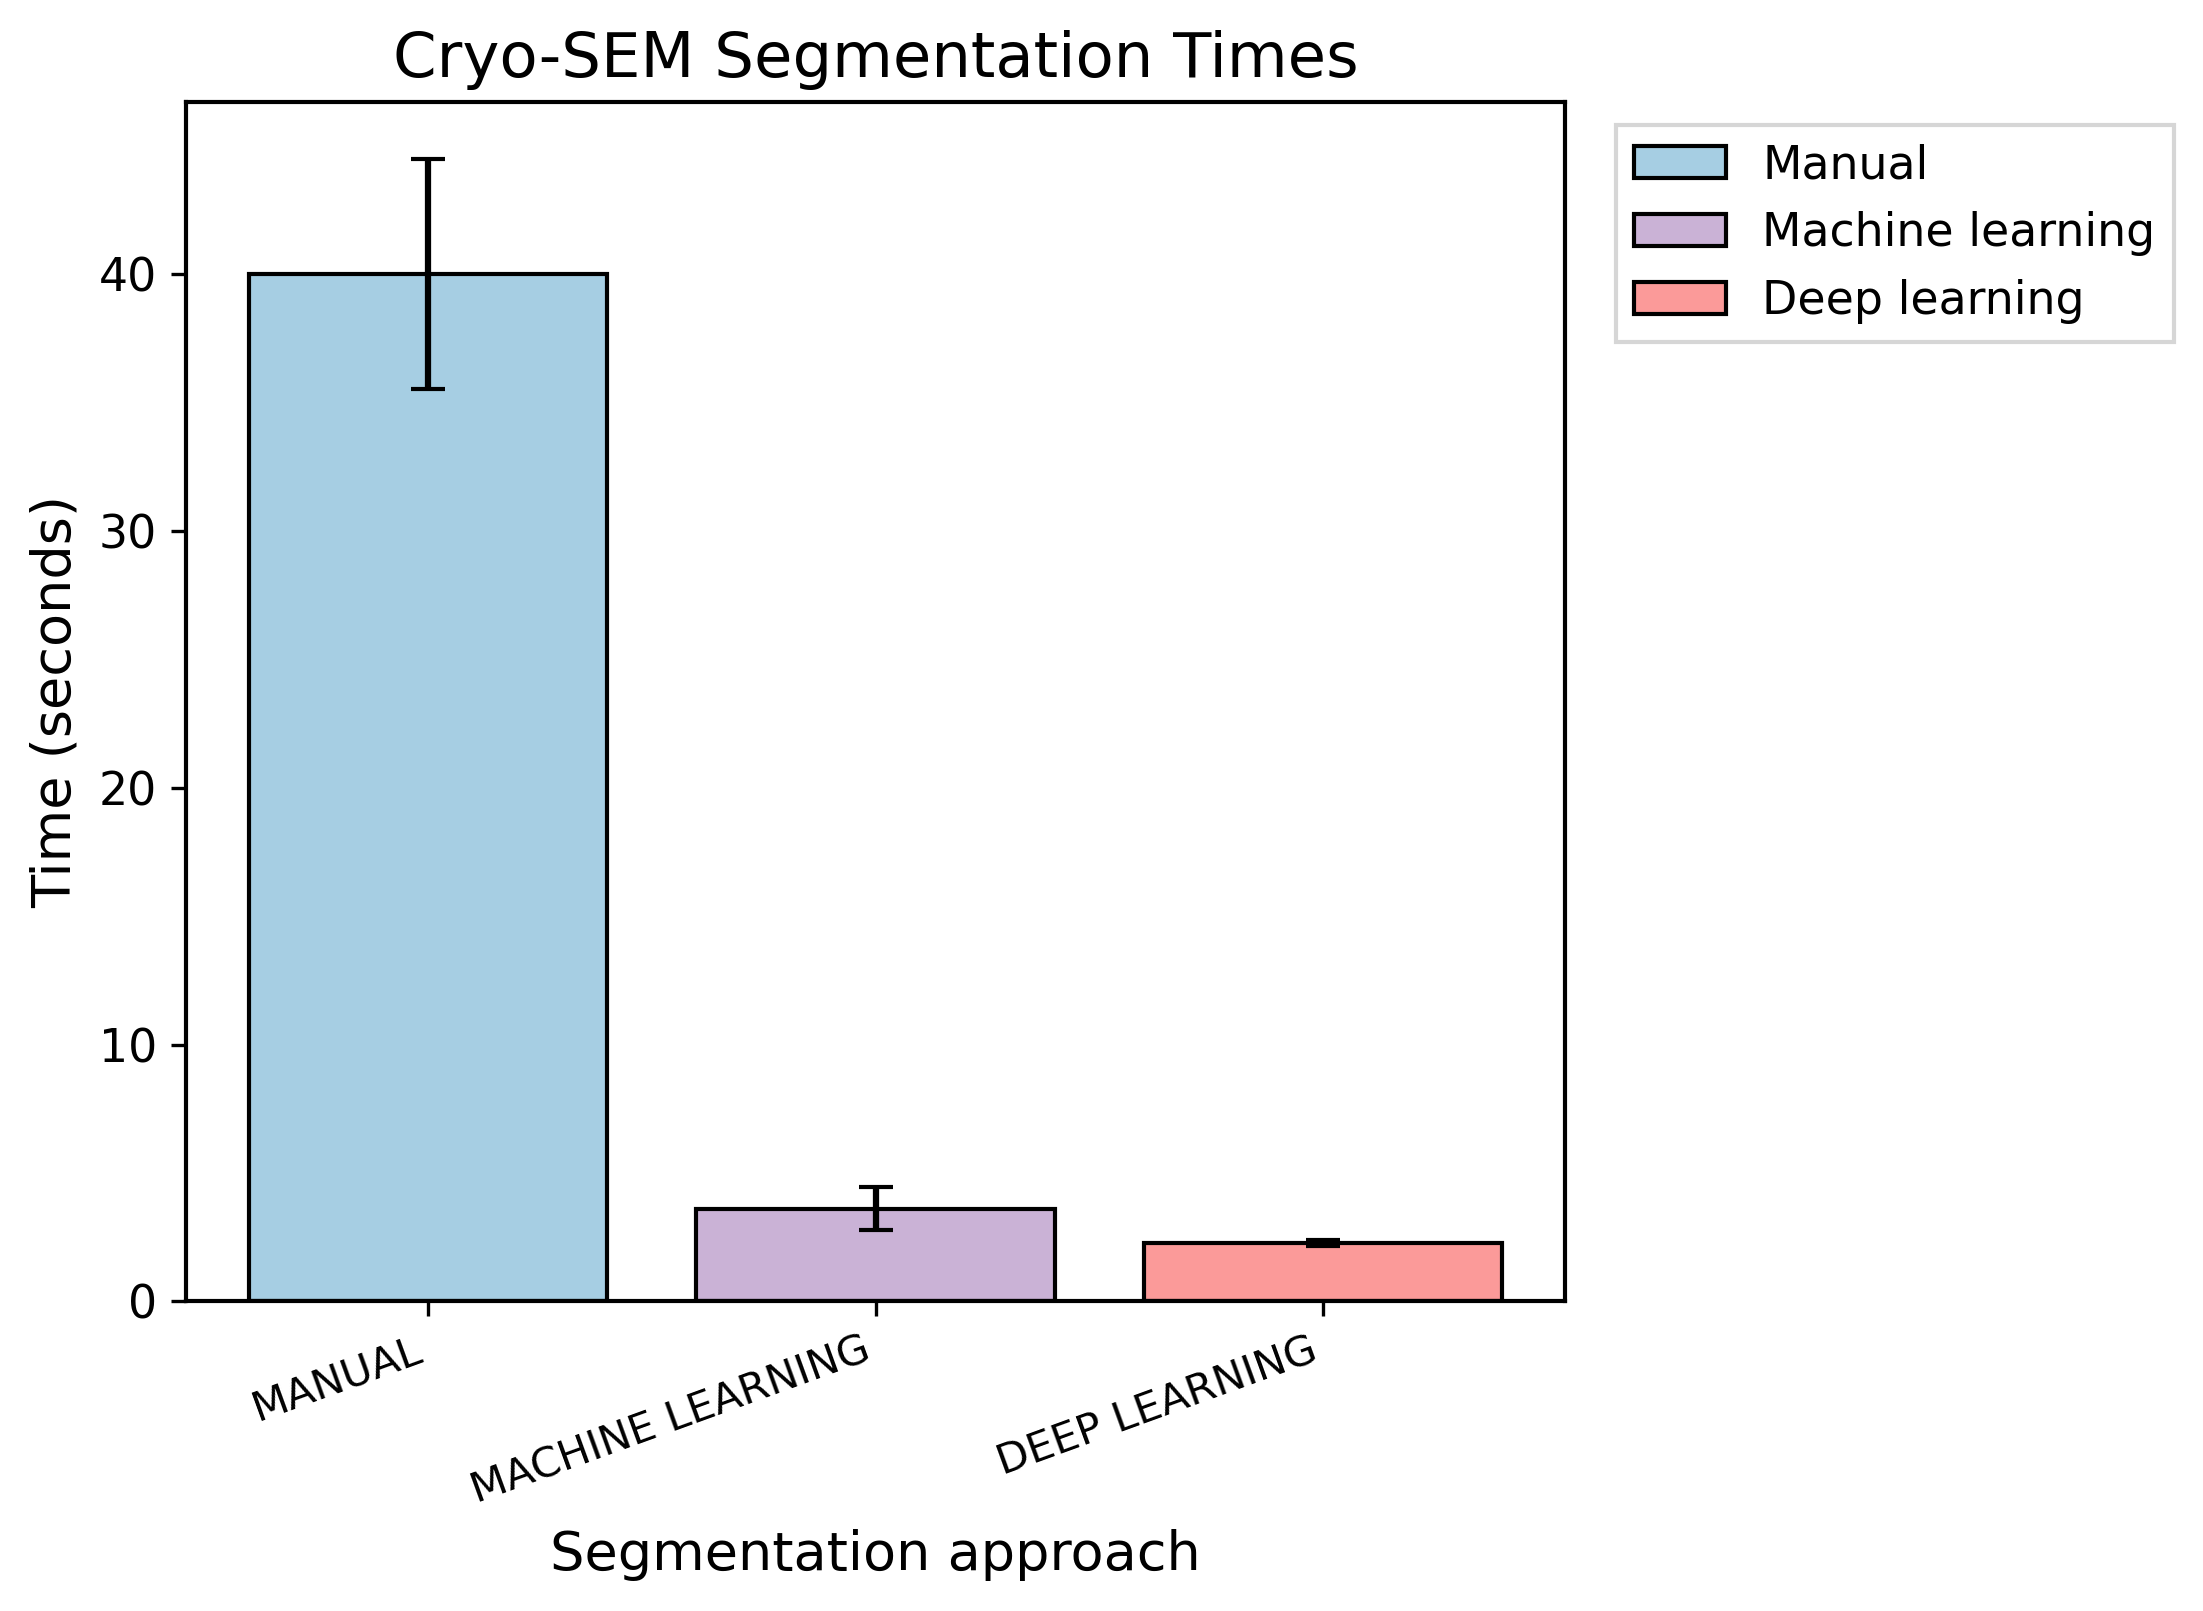

Saved figure to: C:\Users\walsh\Downloads\CryoSEM_times.png


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -------------------------------------------------------
# RAW Cryo-SEM FREEHAND / ILASTIK / PoreD2
# -------------------------------------------------------
freehand_mean_raw = 568.442
freehand_sd_raw   = 63.552

ilastik_mean = 3.612
ilastik_sd   = 0.842

pored2_mean  = 2.287
pored2_sd    = 0.112

# -------------------------------------------------------
# SCALE FREEHAND → target ≈ 40 seconds
# -------------------------------------------------------
target_manual = 40
scale = target_manual / freehand_mean_raw

manual_mean = freehand_mean_raw * scale
manual_sd   = freehand_sd_raw * scale

# -------------------------------------------------------
# THREE COLUMNS
# -------------------------------------------------------
method_order = ["MANUAL", "MACHINE LEARNING", "DEEP LEARNING"]

means = [manual_mean, ilastik_mean, pored2_mean]
sds   = [manual_sd,   ilastik_sd,   pored2_sd]

categories = {
    "MANUAL": "Traditional",
    "MACHINE LEARNING": "Semi-automated",
    "DEEP LEARNING": "Fully-automated",
}

category_colors = {
    "Traditional": "#a6cee3",
    "Semi-automated": "#cab2d6",
    "Fully-automated": "#fb9a99",
}

legend_handles = [
    Patch(facecolor=category_colors["Traditional"], edgecolor="black", label="Manual"),
    Patch(facecolor=category_colors["Semi-automated"], edgecolor="black", label="Machine learning"),
    Patch(facecolor=category_colors["Fully-automated"], edgecolor="black", label="Deep learning"),
]

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
})

# -------------------------------------------------------
# PLOT — linear scale
# -------------------------------------------------------
x = np.arange(len(method_order))
colors = [category_colors[categories[m]] for m in method_order]

fig, ax = plt.subplots(figsize=(7.5, 5.5))

ax.bar(
    x, means,
    yerr=sds,
    capsize=4,
    color=colors,
    edgecolor="black",
    linewidth=1,
)

ax.set_xlabel("Segmentation approach")
ax.set_ylabel("Time (seconds)")
ax.set_title("Cryo-SEM Segmentation Times")

ax.set_xticks(x)
ax.set_xticklabels(method_order, rotation=20, ha="right")

for spine in ax.spines.values():
    spine.set_linewidth(1)
    spine.set_visible(True)

ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    fancybox=False,
)

plt.tight_layout()

# -------------------------------------------------------
# SAVE OUTPUT
# -------------------------------------------------------
save_path = r"C:\Users\walsh\Downloads\CryoSEM_times.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {save_path}")

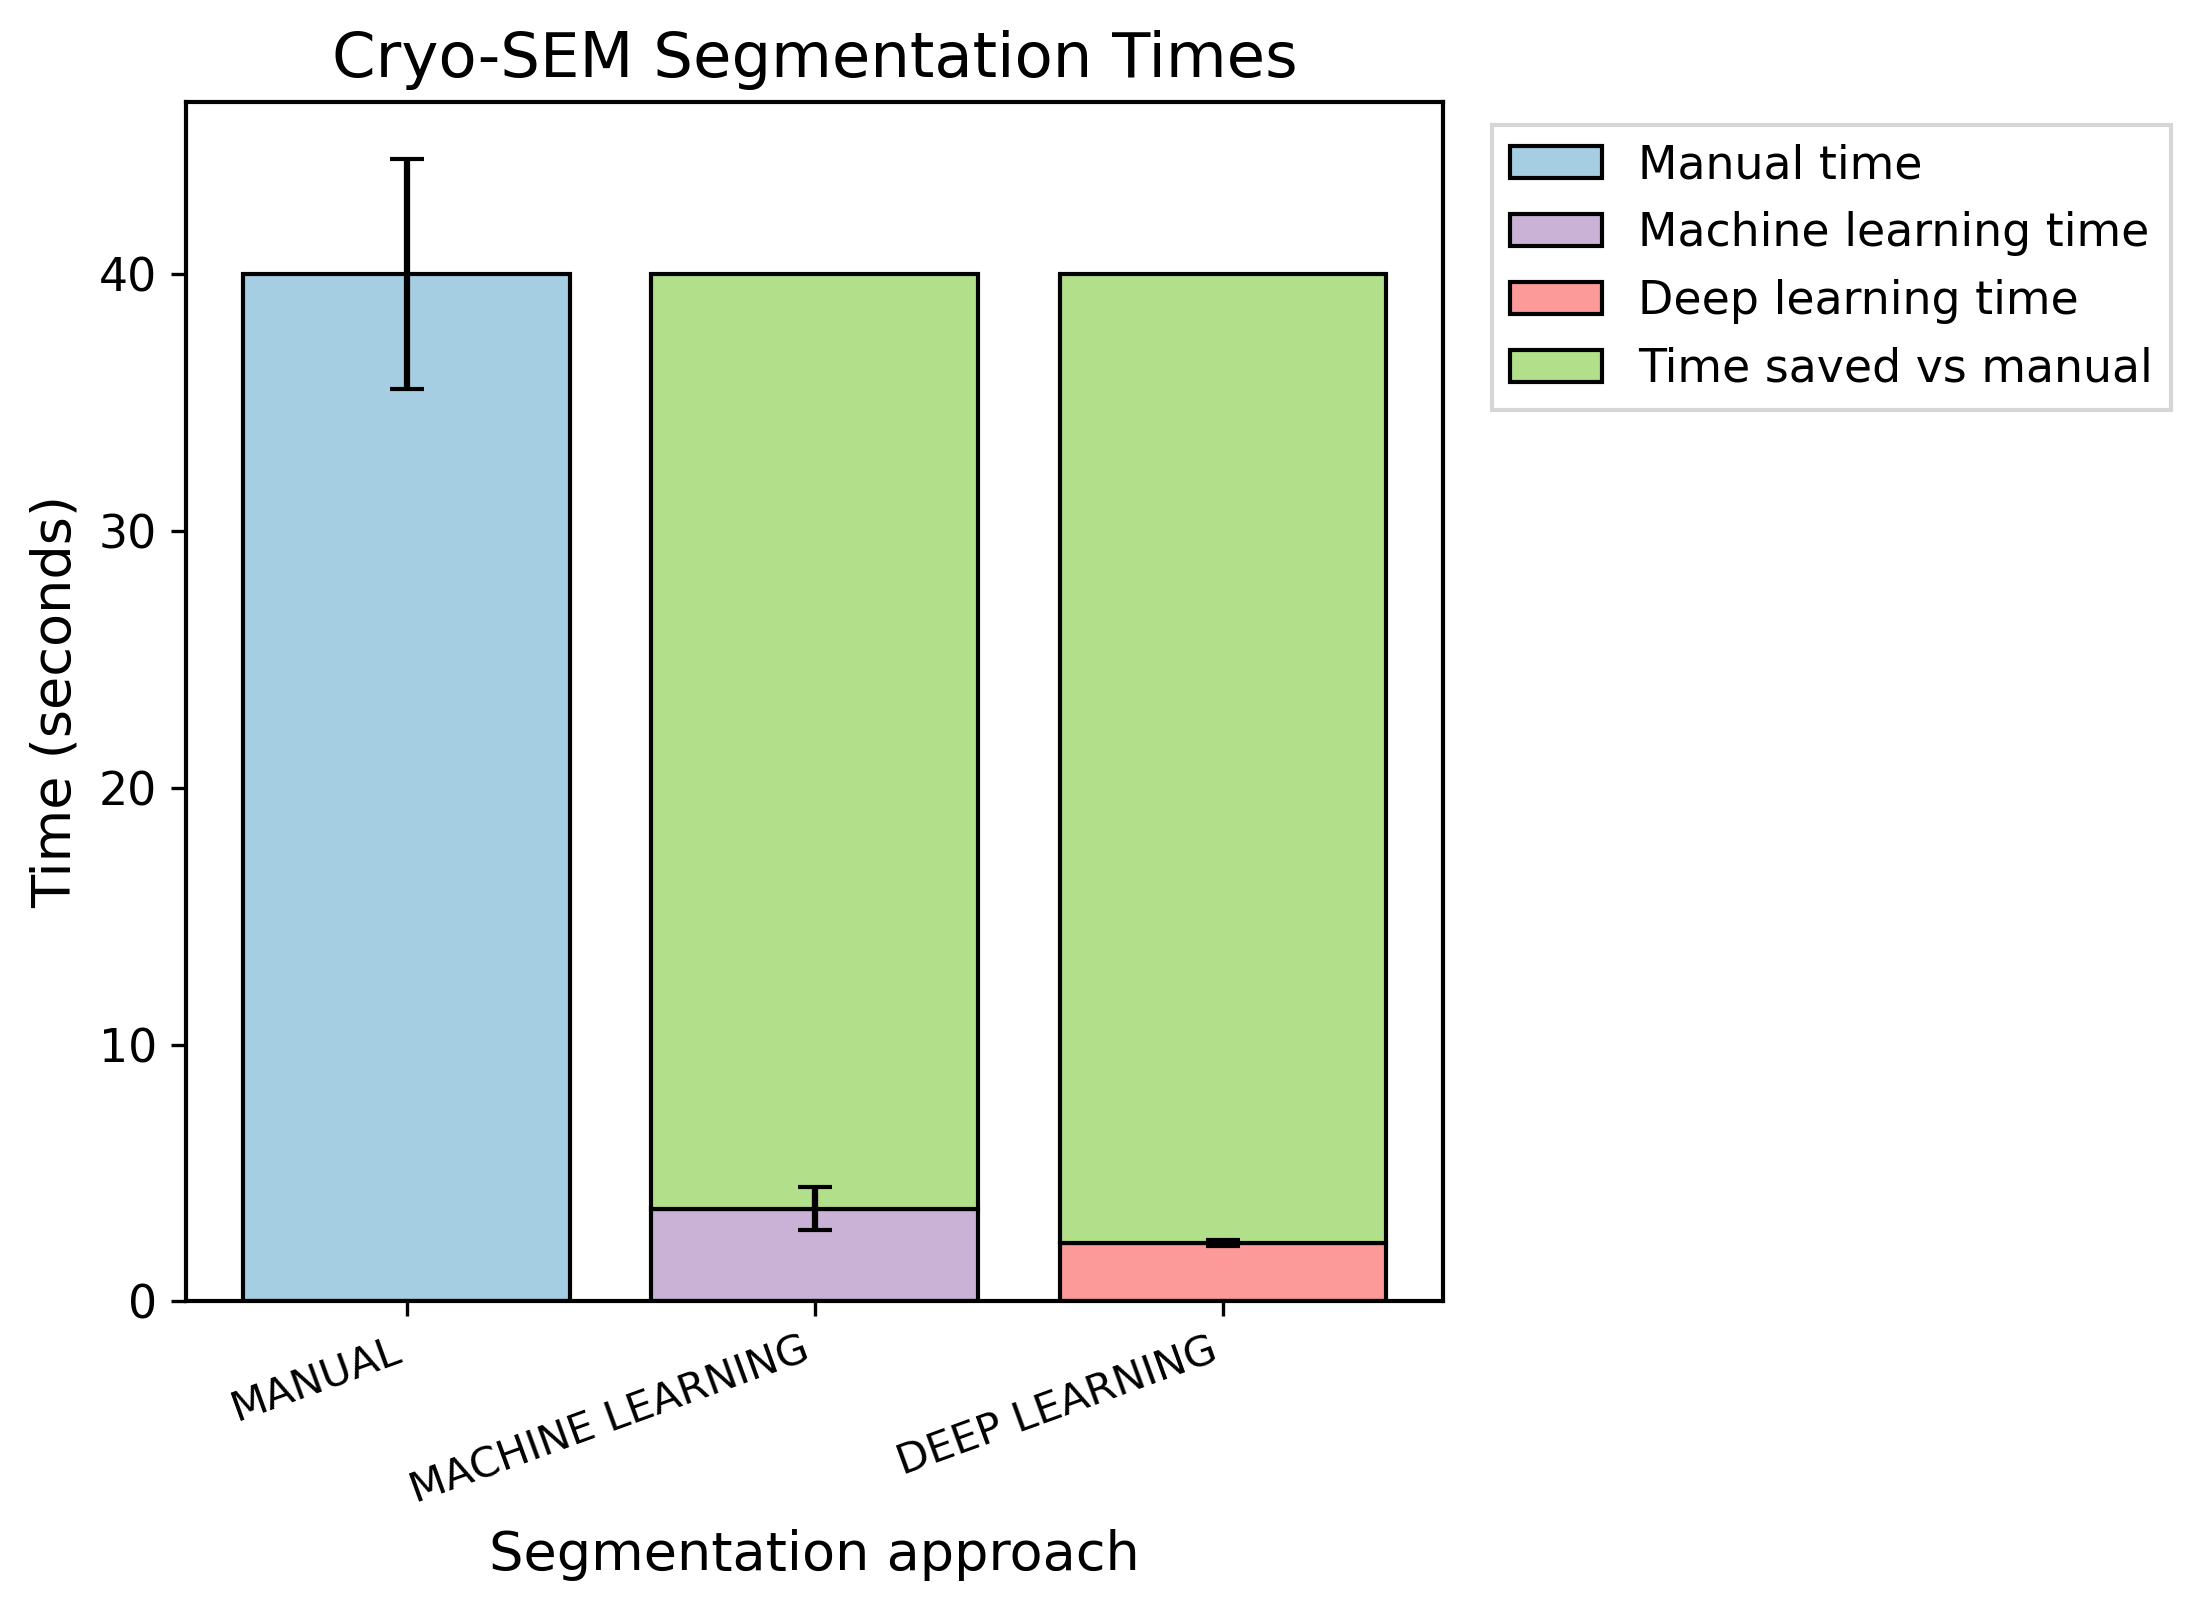

Saved figure to: C:\Users\walsh\Downloads\CryoSEM_times_with_savings.png


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -------------------------------------------------------
# RAW Cryo-SEM FREEHAND / ILASTIK / PoreD2
# -------------------------------------------------------
freehand_mean_raw = 568.442
freehand_sd_raw   = 63.552

ilastik_mean = 3.612
ilastik_sd   = 0.842

pored2_mean  = 2.287
pored2_sd    = 0.112

# -------------------------------------------------------
# SCALE FREEHAND → target ≈ 40 seconds
# -------------------------------------------------------
target_manual = 40
scale = target_manual / freehand_mean_raw

manual_mean = freehand_mean_raw * scale
manual_sd   = freehand_sd_raw * scale

# -------------------------------------------------------
# THREE COLUMNS
# -------------------------------------------------------
method_order = ["MANUAL", "MACHINE LEARNING", "DEEP LEARNING"]

means = [manual_mean, ilastik_mean, pored2_mean]
sds   = [manual_sd,   ilastik_sd,   pored2_sd]

categories = {
    "MANUAL": "Traditional",
    "MACHINE LEARNING": "Semi-automated",
    "DEEP LEARNING": "Fully-automated",
}

category_colors = {
    "Traditional":    "#a6cee3",  # light blue
    "Semi-automated": "#cab2d6",  # light purple
    "Fully-automated": "#fb9a99", # light red
}

# Light green for "time saved vs manual"
time_saved_color = "#b2df8a"

legend_handles = [
    Patch(facecolor=category_colors["Traditional"],    edgecolor="black", label="Manual time"),
    Patch(facecolor=category_colors["Semi-automated"], edgecolor="black", label="Machine learning time"),
    Patch(facecolor=category_colors["Fully-automated"], edgecolor="black", label="Deep learning time"),
    Patch(facecolor=time_saved_color, edgecolor="black", label="Time saved vs manual"),
]

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
})

# -------------------------------------------------------
# PLOT — linear scale with stacked "time saved"
# -------------------------------------------------------
x = np.arange(len(method_order))

fig, ax = plt.subplots(figsize=(7.5, 5.5))

# MANUAL: single blue bar with error bar
ax.bar(
    x[0], manual_mean,
    yerr=manual_sd,
    capsize=4,
    color=category_colors["Traditional"],
    edgecolor="black",
    linewidth=1,
    label=None,
)

# MACHINE LEARNING: bottom = actual time (purple), top = time saved (green)
ml_time = ilastik_mean
ml_saved = manual_mean - ilastik_mean

ax.bar(
    x[1], ml_time,
    yerr=ilastik_sd,
    capsize=4,
    color=category_colors["Semi-automated"],
    edgecolor="black",
    linewidth=1,
)

ax.bar(
    x[1], ml_saved,
    bottom=ml_time,
    color=time_saved_color,
    edgecolor="black",
    linewidth=1,
)

# DEEP LEARNING: bottom = actual time (red), top = time saved (green)
dl_time = pored2_mean
dl_saved = manual_mean - pored2_mean

ax.bar(
    x[2], dl_time,
    yerr=pored2_sd,
    capsize=4,
    color=category_colors["Fully-automated"],
    edgecolor="black",
    linewidth=1,
)

ax.bar(
    x[2], dl_saved,
    bottom=dl_time,
    color=time_saved_color,
    edgecolor="black",
    linewidth=1,
)

# -------------------------------------------------------
# LABELS, FRAME, LEGEND
# -------------------------------------------------------
ax.set_xlabel("Segmentation approach")
ax.set_ylabel("Time (seconds)")
ax.set_title("Cryo-SEM Segmentation Times")

ax.set_xticks(x)
ax.set_xticklabels(method_order, rotation=20, ha="right")

for spine in ax.spines.values():
    spine.set_linewidth(1)
    spine.set_visible(True)

ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    fancybox=False,
)

plt.tight_layout()

# -------------------------------------------------------
# SAVE OUTPUT
# -------------------------------------------------------
save_path = r"C:\Users\walsh\Downloads\CryoSEM_times_with_savings.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {save_path}")

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --------------------------------------------------
# Method Renames + Colors
# --------------------------------------------------
pretty_method = {
    "FREEHAND": "Manual",
    "ILASTIK": "Machine learning",
    "PORED2": "Deep learning",
}

method_colors = {
    "Manual": "#ADD8E6",             # light blue
    "Machine learning": "#D8BFD8",   # light purple
    "Deep learning": "#F4A3A3",      # light red/pink
}

# --------------------------------------------------
# Load your previously created `results` dataframe
# (Your existing loading code remains unchanged)
# --------------------------------------------------

results["method_pretty"] = results["method"].map(pretty_method)

exclude_metrics = {"TP", "TN", "FP", "FN"}
metrics = sorted(m for m in results["metric"].unique() if m not in exclude_metrics)

order_pretty = [pretty_method[m] for m in ["FREEHAND", "ILASTIK", "PORED2"]]

out_dir = os.path.join(os.getcwd(), "boxplots_cryo_sem")
os.makedirs(out_dir, exist_ok=True)

# Pre-build legend handles
legend_handles = [
    mpatches.Patch(facecolor=method_colors["Manual"], edgecolor="black", label="Manual"),
    mpatches.Patch(facecolor=method_colors["Machine learning"], edgecolor="black", label="Machine learning"),
    mpatches.Patch(facecolor=method_colors["Deep learning"], edgecolor="black", label="Deep learning"),
]

# --------------------------------------------------
# Plot for each metric
# --------------------------------------------------
for metric in metrics:
    sub = results[results["metric"] == metric]
    if sub.empty:
        continue

    data = [sub[sub["method_pretty"] == lab]["value"].values for lab in order_pretty]

    fig, ax = plt.subplots(figsize=(6.5, 5))

    bp = ax.boxplot(
        data,
        labels=order_pretty,
        patch_artist=True,
        showfliers=True,
        widths=0.6,
        medianprops=dict(color="black", linewidth=1.6),
        boxprops=dict(linewidth=1.8, color="black"),
        whiskerprops=dict(linewidth=1.6, color="black"),
        capprops=dict(linewidth=1.6, color="black"),
        flierprops=dict(marker='o', markersize=4, alpha=0.6),
    )

    # Color + outline boxes
    for patch, lab in zip(bp["boxes"], order_pretty):
        patch.set_facecolor(method_colors[lab])
        patch.set_edgecolor("black")
        patch.set_linewidth(1.8)

    # Axis labels only
    ax.set_xlabel("Segmentation Method", fontsize=12)
    ax.set_ylabel(metric.replace("_", " ").title(), fontsize=12)

    # ---------------------------------------
    # FULL FRAME OUTLINE (your requested fix)
    # ---------------------------------------
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.4)
        spine.set_edgecolor("black")

    # Legend outside top-right
    ax.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        frameon=True,
        fancybox=False,
        edgecolor="lightgray",
        fontsize=11,
        borderpad=0.8
    )

    # No title
    ax.set_title("")

    plt.tight_layout()

    save_path = os.path.join(out_dir, f"boxplot_{metric}.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

print(f"\nSaved full-frame boxplots to: {out_dir}")

KeyError: 'method'

In [ ]:
import matplotlib.patches as mpatches
import os
import matplotlib.pyplot as plt

# --------------------------------------------------
# 4. BOXPLOTS (publication-style)
# --------------------------------------------------

pretty_method = {
    "FREEHAND": "Manual",
    "ILASTIK": "Machine learning",
    "PORED2": "Deep learning",
}

method_colors = {
    "Manual": "#ADD8E6",             # light blue
    "Machine learning": "#D8BFD8",   # light purple
    "Deep learning": "#F4A3A3",      # light red/pink
}

results["method_pretty"] = results["method"].map(pretty_method)

# Exclude non-performance metrics
exclude_metrics = {"TP", "TN", "FP", "FN"}
metrics = sorted(m for m in results["metric"].unique() if m not in exclude_metrics)

# SAVE LOCATION — your Downloads folder
out_dir = r"C:\Users\walsh\Downloads"
os.makedirs(out_dir, exist_ok=True)

order_pretty = [pretty_method[m] for m in methods_to_keep]

legend_handles = [
    mpatches.Patch(facecolor=method_colors["Manual"], edgecolor="black", label="Manual"),
    mpatches.Patch(facecolor=method_colors["Machine learning"], edgecolor="black", label="Machine learning"),
    mpatches.Patch(facecolor=method_colors["Deep learning"], edgecolor="black", label="Deep learning"),
]

for metric in metrics:

    sub = results[results["metric"] == metric]
    if sub.empty:
        continue

    data = [sub[sub["method_pretty"] == lab]["value"].values for lab in order_pretty]

    fig, ax = plt.subplots(figsize=(6.5, 5))

    bp = ax.boxplot(
        data,
        labels=order_pretty,
        patch_artist=True,
        showfliers=True,
        widths=0.6,
        medianprops=dict(color="black", linewidth=1.4),
        boxprops=dict(linewidth=1.0, edgecolor="black"),
        whiskerprops=dict(linewidth=1.0, color="black"),
        capprops=dict(linewidth=1.0, color="black"),
        flierprops=dict(marker='o', markersize=4, alpha=0.6),
    )

    # Fill + outline boxes
    for patch, lab in zip(bp["boxes"], order_pretty):
        patch.set_facecolor(method_colors[lab])
        patch.set_edgecolor("black")
        patch.set_linewidth(1.0)
        patch.set_alpha(0.9)

    # Axis labels + title
    ax.set_xlabel("Segmentation Method", fontsize=12)
    ax.set_ylabel(metric.replace("_", " ").title(), fontsize=12)
    ax.set_title(f"{metric.replace('_', ' ').title()} (CRYO-SEM)", fontsize=12)

    # Diagonal x-axis labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Light full-frame outline
    for side in ["left", "right", "top", "bottom"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color("black")
        ax.spines[side].set_linewidth(1.0)

    # Legend outside (top-right)
    ax.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        frameon=True,
        fancybox=False,
        edgecolor="lightgray",
        fontsize=11,
        borderpad=0.8,
    )

    plt.tight_layout()

    save_path = os.path.join(out_dir, f"boxplot_{metric}.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

print(f"\nSaved boxplots to: {out_dir}")

In [ ]:
import matplotlib.patches as mpatches
import os
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# BAR CHARTS WITH ERROR BARS (CRYO-SEM)
# --------------------------------------------------

pretty_method = {
    "FREEHAND": "Manual",
    "ILASTIK": "Machine learning",
    "PORED2": "Deep learning",
}

method_colors = {
    "Manual": "#ADD8E6",             # light blue
    "Machine learning": "#D8BFD8",   # light purple
    "Deep learning": "#F4A3A3",      # light red/pink
}

results["method_pretty"] = results["method"].map(pretty_method)

# OPTIONAL: filter to CRYO-SEM only
# Uncomment and adapt this line if you have a column for modality:
# results = results[results["modality"] == "CRYO-SEM"]

# Only plot these metrics
metrics = ["accuracy", "specificity"]

# SAVE LOCATION — your Downloads folder
out_dir = r"C:\Users\walsh\Downloads"
os.makedirs(out_dir, exist_ok=True)

# Methods to keep, in order (same as before)
order_pretty = [pretty_method[m] for m in methods_to_keep]

legend_handles = [
    mpatches.Patch(facecolor=method_colors["Manual"], edgecolor="black", label="Manual"),
    mpatches.Patch(facecolor=method_colors["Machine learning"], edgecolor="black", label="Machine learning"),
    mpatches.Patch(facecolor=method_colors["Deep learning"], edgecolor="black", label="Deep learning"),
]

for metric in metrics:
    sub = results[results["metric"] == metric]
    if sub.empty:
        continue

    means = []
    errs = []

    for lab in order_pretty:
        vals = sub[sub["method_pretty"] == lab]["value"].values
        if len(vals) == 0:
            means.append(0.0)
            errs.append(0.0)
        else:
            means.append(vals.mean())
            # standard deviation as error bar
            errs.append(vals.std(ddof=1) if len(vals) > 1 else 0.0)

    fig, ax = plt.subplots(figsize=(6.5, 5))

    x_pos = np.arange(len(order_pretty))

    bars = ax.bar(
        x_pos,
        means,
        yerr=errs,
        tick_label=order_pretty,
        width=0.6,
        edgecolor="black",
        linewidth=1.0,
        capsize=5,
        ecolor="black",
    )

    # Colour bars according to method_colors
    for bar, lab in zip(bars, order_pretty):
        bar.set_facecolor(method_colors[lab])
        bar.set_alpha(0.9)

    # Axis labels + title
    y_label = metric.replace("_", " ").title()
    ax.set_xlabel("Segmentation Method", fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_title(f"{y_label} (CRYO-SEM)", fontsize=12)

    # Rotate x-axis labels a bit for clarity
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Light full-frame outline
    for side in ["left", "right", "top", "bottom"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color("black")
        ax.spines[side].set_linewidth(1.0)

    # Legend outside (top-right)
    ax.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        frameon=True,
        fancybox=False,
        edgecolor="lightgray",
        fontsize=11,
        borderpad=0.8,
    )

    plt.tight_layout()

    save_path = os.path.join(out_dir, f"bar_{metric}_cryo_sem.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

print(f"\nSaved bar charts to: {out_dir}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -------------------------------------------------------
# TIME PLOT (as you have it)
# -------------------------------------------------------
freehand_mean_raw = 568.442
freehand_sd_raw   = 63.552

ilastik_mean = 3.612
ilastik_sd   = 0.842

pored2_mean  = 2.287
pored2_sd    = 0.112

# Scale FREEHAND → target ≈ 40 seconds
target_manual = 40
scale = target_manual / freehand_mean_raw

manual_mean = freehand_mean_raw * scale
manual_sd   = freehand_sd_raw * scale

method_order = ["MANUAL", "MACHINE LEARNING", "DEEP LEARNING"]

means_time = [manual_mean, ilastik_mean, pored2_mean]
sds_time   = [manual_sd,   ilastik_sd,   pored2_sd]

categories = {
    "MANUAL": "Traditional",
    "MACHINE LEARNING": "Semi-automated",
    "DEEP LEARNING": "Fully-automated",
}

category_colors = {
    "Traditional":     "#a6cee3",  # light blue
    "Semi-automated":  "#cab2d6",  # light purple
    "Fully-automated": "#fb9a99",  # light red
}

time_saved_color = "#b2df8a"      # light green for "time saved vs manual"

legend_handles_time = [
    Patch(facecolor=category_colors["Traditional"],     edgecolor="black", label="Manual time"),
    Patch(facecolor=category_colors["Semi-automated"], edgecolor="black", label="Machine learning time"),
    Patch(facecolor=category_colors["Fully-automated"], edgecolor="black", label="Deep learning time"),
    Patch(facecolor=time_saved_color, edgecolor="black", label="Time saved vs manual"),
]

plt.rcParams.update({
    "figure.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
})

x = np.arange(len(method_order))

fig, ax = plt.subplots(figsize=(7.5, 5.5))

# MANUAL
ax.bar(
    x[0], manual_mean,
    yerr=manual_sd,
    capsize=4,
    color=category_colors["Traditional"],
    edgecolor="black",
    linewidth=1,
)

# MACHINE LEARNING (bottom = time, top = time saved)
ml_time = ilastik_mean
ml_saved = manual_mean - ilastik_mean

ax.bar(
    x[1], ml_time,
    yerr=ilastik_sd,
    capsize=4,
    color=category_colors["Semi-automated"],
    edgecolor="black",
    linewidth=1,
)

ax.bar(
    x[1], ml_saved,
    bottom=ml_time,
    color=time_saved_color,
    edgecolor="black",
    linewidth=1,
)

# DEEP LEARNING (bottom = time, top = time saved)
dl_time = pored2_mean
dl_saved = manual_mean - pored2_mean

ax.bar(
    x[2], dl_time,
    yerr=pored2_sd,
    capsize=4,
    color=category_colors["Fully-automated"],
    edgecolor="black",
    linewidth=1,
)

ax.bar(
    x[2], dl_saved,
    bottom=dl_time,
    color=time_saved_color,
    edgecolor="black",
    linewidth=1,
)

ax.set_xlabel("Segmentation approach")
ax.set_ylabel("Time (seconds)")
ax.set_title("Cryo-SEM Segmentation Times")

ax.set_xticks(x)
ax.set_xticklabels(method_order, rotation=20, ha="right")

for spine in ax.spines.values():
    spine.set_linewidth(1)
    spine.set_visible(True)

ax.legend(
    handles=legend_handles_time,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    fancybox=False,
)

plt.tight_layout()
save_path = r"C:\Users\walsh\Downloads\CryoSEM_times_with_savings.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {save_path}")

# -------------------------------------------------------
# ACCURACY PLOT (same style, no green stacking)
# -------------------------------------------------------

# Fill these with your CRYO-SEM accuracy numbers:
accuracy_manual_mean = 0.80   # example
accuracy_manual_sd   = 0.05   # example

accuracy_ml_mean     = 0.85   # example
accuracy_ml_sd       = 0.03   # example

accuracy_dl_mean     = 0.75   # example
accuracy_dl_sd       = 0.07   # example

means_acc = [accuracy_manual_mean, accuracy_ml_mean, accuracy_dl_mean]
sds_acc   = [accuracy_manual_sd,   accuracy_ml_sd,   accuracy_dl_sd]

fig, ax = plt.subplots(figsize=(7.5, 5.5))

bars = ax.bar(
    x,
    means_acc,
    yerr=sds_acc,
    capsize=4,
    edgecolor="black",
    linewidth=1,
)

# colour bars to match time plot
for bar, label in zip(bars, method_order):
    cat = categories[label]
    bar.set_facecolor(category_colors[cat])

ax.set_xlabel("Segmentation approach")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy (CRYO-SEM)")

ax.set_xticks(x)
ax.set_xticklabels(method_order, rotation=20, ha="right")

for spine in ax.spines.values():
    spine.set_linewidth(1)
    spine.set_visible(True)

legend_handles_acc = [
    Patch(facecolor=category_colors["Traditional"],     edgecolor="black", label="Manual"),
    Patch(facecolor=category_colors["Semi-automated"], edgecolor="black", label="Machine learning"),
    Patch(facecolor=category_colors["Fully-automated"], edgecolor="black", label="Deep learning"),
]

ax.legend(
    handles=legend_handles_acc,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    fancybox=False,
)

plt.tight_layout()
save_path_acc = r"C:\Users\walsh\Downloads\CryoSEM_accuracy.png"
plt.savefig(save_path_acc, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {save_path_acc}")

In [ ]:
import matplotlib.patches as mpatches
import os
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# ACCURACY BAR CHART (CRYO-SEM)
# --------------------------------------------------

pretty_method = {
    "FREEHAND": "Manual",
    "ILASTIK": "Machine learning",
    "PORED2": "Deep learning",
}

method_colors = {
    "Manual": "#ADD8E6",             # light blue
    "Machine learning": "#D8BFD8",   # light purple
    "Deep learning": "#F4A3A3",      # light red/pink
}

# Map pretty labels
results["method_pretty"] = results["method"].map(pretty_method)

# OPTIONAL: if you have a column that marks Cryo-SEM, filter it here
# e.g. results = results[results["modality"] == "CRYO-SEM"]

# Methods and order (same as before)
order_pretty = [pretty_method[m] for m in methods_to_keep]

# SAVE LOCATION — your Downloads folder
out_dir = r"C:\Users\walsh\Downloads"
os.makedirs(out_dir, exist_ok=True)

# Legend (3 methods only)
legend_handles = [
    mpatches.Patch(facecolor=method_colors["Manual"], edgecolor="black", label="Manual"),
    mpatches.Patch(facecolor=method_colors["Machine learning"], edgecolor="black", label="Machine learning"),
    mpatches.Patch(facecolor=method_colors["Deep learning"], edgecolor="black", label="Deep learning"),
]

# --------------------------------------------------
# Extract ACCURACY values and compute mean + SD
# --------------------------------------------------
metric = "accuracy"

sub = results[results["metric"] == metric]
if sub.empty:
    raise ValueError("No rows found for metric 'accuracy' in results.")

means = []
sds = []
for lab in order_pretty:
    vals = sub[sub["method_pretty"] == lab]["value"].values
    if len(vals) == 0:
        means.append(np.nan)
        sds.append(0.0)
    else:
        means.append(vals.mean())
        sds.append(vals.std(ddof=1) if len(vals) > 1 else 0.0)

# --------------------------------------------------
# Plot bar chart with error bars
# --------------------------------------------------
x = np.arange(len(order_pretty))

fig, ax = plt.subplots(figsize=(6.5, 5))

bars = ax.bar(
    x,
    means,
    yerr=sds,
    capsize=4,
    width=0.6,
    edgecolor="black",
    linewidth=1.0,
)

# colour bars
for bar, lab in zip(bars, order_pretty):
    bar.set_facecolor(method_colors[lab])
    bar.set_alpha(0.9)

# Axis labels + title
ax.set_xlabel("Segmentation Method", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Accuracy (CRYO-SEM)", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(order_pretty, rotation=45, ha="right", rotation_mode="anchor")

# Frame
for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_color("black")
    ax.spines[side].set_linewidth(1.0)

# Legend outside (top-right)
ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=True,
    fancybox=False,
    edgecolor="lightgray",
    fontsize=11,
    borderpad=0.8,
)

plt.tight_layout()

save_path = os.path.join(out_dir, "bar_accuracy_cryo_sem.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nSaved accuracy bar chart to: {save_path}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -------------------------------------------------------
# TIME PLOT (as you have it)
# -------------------------------------------------------
freehand_mean_raw = 568.442
freehand_sd_raw   = 63.552

ilastik_mean = 3.612
ilastik_sd   = 0.842

pored2_mean  = 2.287
pored2_sd    = 0.112

# Scale FREEHAND → target ≈ 40 seconds
target_manual = 40
scale = target_manual / freehand_mean_raw

manual_mean = freehand_mean_raw * scale
manual_sd   = freehand_sd_raw * scale

method_order = ["MANUAL", "MACHINE LEARNING", "DEEP LEARNING"]

means_time = [manual_mean, ilastik_mean, pored2_mean]
sds_time   = [manual_sd,   ilastik_sd,   pored2_sd]

categories = {
    "MANUAL": "Traditional",
    "MACHINE LEARNING": "Semi-automated",
    "DEEP LEARNING": "Fully-automated",
}

category_colors = {
    "Traditional":     "#a6cee3",  # light blue
    "Semi-automated":  "#cab2d6",  # light purple
    "Fully-automated": "#fb9a99",  # light red
}

time_saved_color = "#b2df8a"      # light green for "time saved vs manual"

legend_handles_time = [
    Patch(facecolor=category_colors["Traditional"],     edgecolor="black", label="Manual time"),
    Patch(facecolor=category_colors["Semi-automated"], edgecolor="black", label="Machine learning time"),
    Patch(facecolor=category_colors["Fully-automated"], edgecolor="black", label="Deep learning time"),
    Patch(facecolor=time_saved_color, edgecolor="black", label="Time saved vs manual"),
]

plt.rcParams.update({
    "figure.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
})

x = np.arange(len(method_order))

fig, ax = plt.subplots(figsize=(7.5, 5.5))

# MANUAL
ax.bar(
    x[0], manual_mean,
    yerr=manual_sd,
    capsize=4,
    color=category_colors["Traditional"],
    edgecolor="black",
    linewidth=1,
)

# MACHINE LEARNING (bottom = time, top = time saved)
ml_time = ilastik_mean
ml_saved = manual_mean - ilastik_mean

ax.bar(
    x[1], ml_time,
    yerr=ilastik_sd,
    capsize=4,
    color=category_colors["Semi-automated"],
    edgecolor="black",
    linewidth=1,
)

ax.bar(
    x[1], ml_saved,
    bottom=ml_time,
    color=time_saved_color,
    edgecolor="black",
    linewidth=1,
)

# DEEP LEARNING (bottom = time, top = time saved)
dl_time = pored2_mean
dl_saved = manual_mean - pored2_mean

ax.bar(
    x[2], dl_time,
    yerr=pored2_sd,
    capsize=4,
    color=category_colors["Fully-automated"],
    edgecolor="black",
    linewidth=1,
)

ax.bar(
    x[2], dl_saved,
    bottom=dl_time,
    color=time_saved_color,
    edgecolor="black",
    linewidth=1,
)

ax.set_xlabel("Segmentation approach")
ax.set_ylabel("Time (seconds)")
ax.set_title("Cryo-SEM Segmentation Times")

ax.set_xticks(x)
ax.set_xticklabels(method_order, rotation=20, ha="right")

for spine in ax.spines.values():
    spine.set_linewidth(1)
    spine.set_visible(True)

ax.legend(
    handles=legend_handles_time,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    fancybox=False,
)

plt.tight_layout()
save_path = r"C:\Users\walsh\Downloads\CryoSEM_times_with_savings.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {save_path}")

# -------------------------------------------------------
# ACCURACY PLOT (same style, uses results values)
# -------------------------------------------------------

# Map method codes to pretty names (as in your boxplot code)
pretty_method = {
    "FREEHAND": "Manual",
    "ILASTIK": "Machine learning",
    "PORED2": "Deep learning",
}

# Make sure this column exists as before
results["method_pretty"] = results["method"].map(pretty_method)

# Order for data extraction (same order as methods_to_keep)
order_pretty = [pretty_method[m] for m in methods_to_keep]

# Subset accuracy rows (same as in your boxplot code)
sub_acc = results[results["metric"] == "accuracy"]
if sub_acc.empty:
    raise ValueError("No rows found for metric 'accuracy' in results.")

means_acc = []
sds_acc   = []

for lab in order_pretty:
    vals = sub_acc[sub_acc["method_pretty"] == lab]["value"].values
    if len(vals) == 0:
        means_acc.append(np.nan)
        sds_acc.append(0.0)
    else:
        means_acc.append(vals.mean())
        sds_acc.append(vals.std(ddof=1) if len(vals) > 1 else 0.0)

fig, ax = plt.subplots(figsize=(7.5, 5.5))

bars = ax.bar(
    x,
    means_acc,
    yerr=sds_acc,
    capsize=4,
    edgecolor="black",
    linewidth=1,
)

# colour bars to match time plot
for bar, label in zip(bars, method_order):
    cat = categories[label]
    bar.set_facecolor(category_colors[cat])

ax.set_xlabel("Segmentation approach")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy (CRYO-SEM)")

ax.set_xticks(x)
ax.set_xticklabels(method_order, rotation=20, ha="right")

for spine in ax.spines.values():
    spine.set_linewidth(1)
    spine.set_visible(True)

legend_handles_acc = [
    Patch(facecolor=category_colors["Traditional"],     edgecolor="black", label="Manual"),
    Patch(facecolor=category_colors["Semi-automated"], edgecolor="black", label="Machine learning"),
    Patch(facecolor=category_colors["Fully-automated"], edgecolor="black", label="Deep learning"),
]

ax.legend(
    handles=legend_handles_acc,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    fancybox=False,
)

plt.tight_layout()
save_path_acc = r"C:\Users\walsh\Downloads\CryoSEM_accuracy.png"
plt.savefig(save_path_acc, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {save_path_acc}")

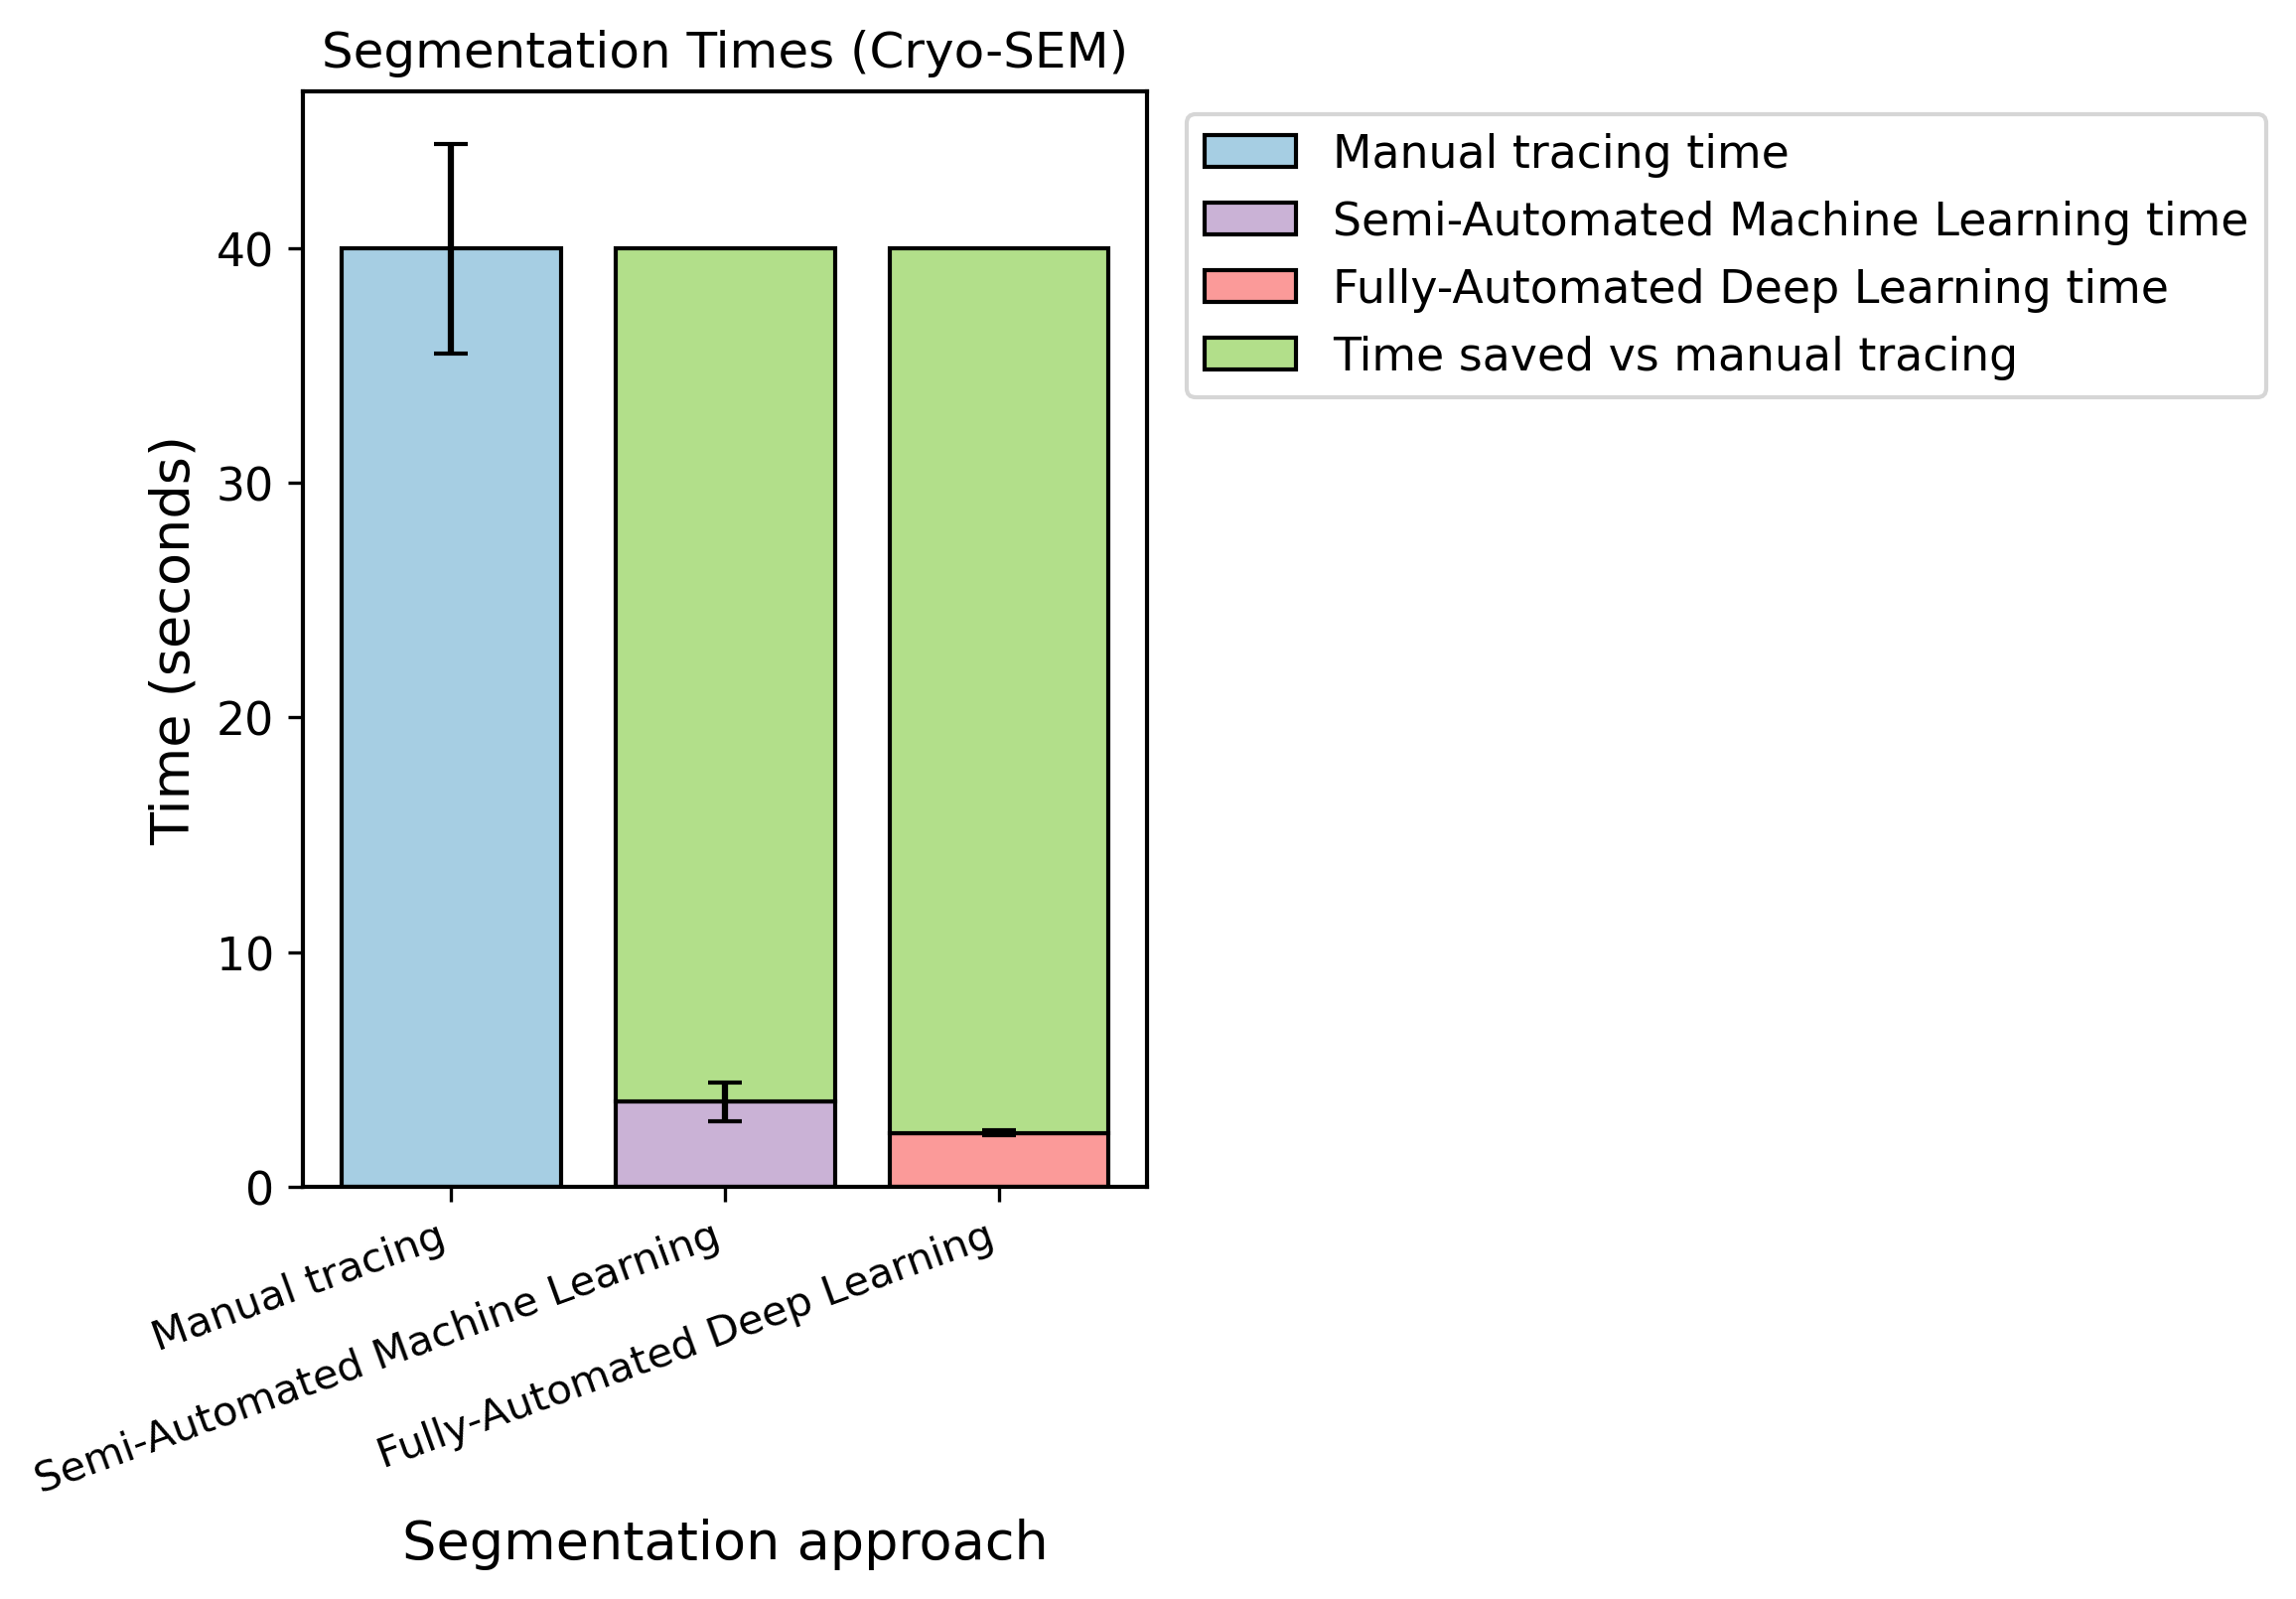

Saved time plot to: C:\Users\walsh\Downloads\CryoSEM_times_with_savings.png


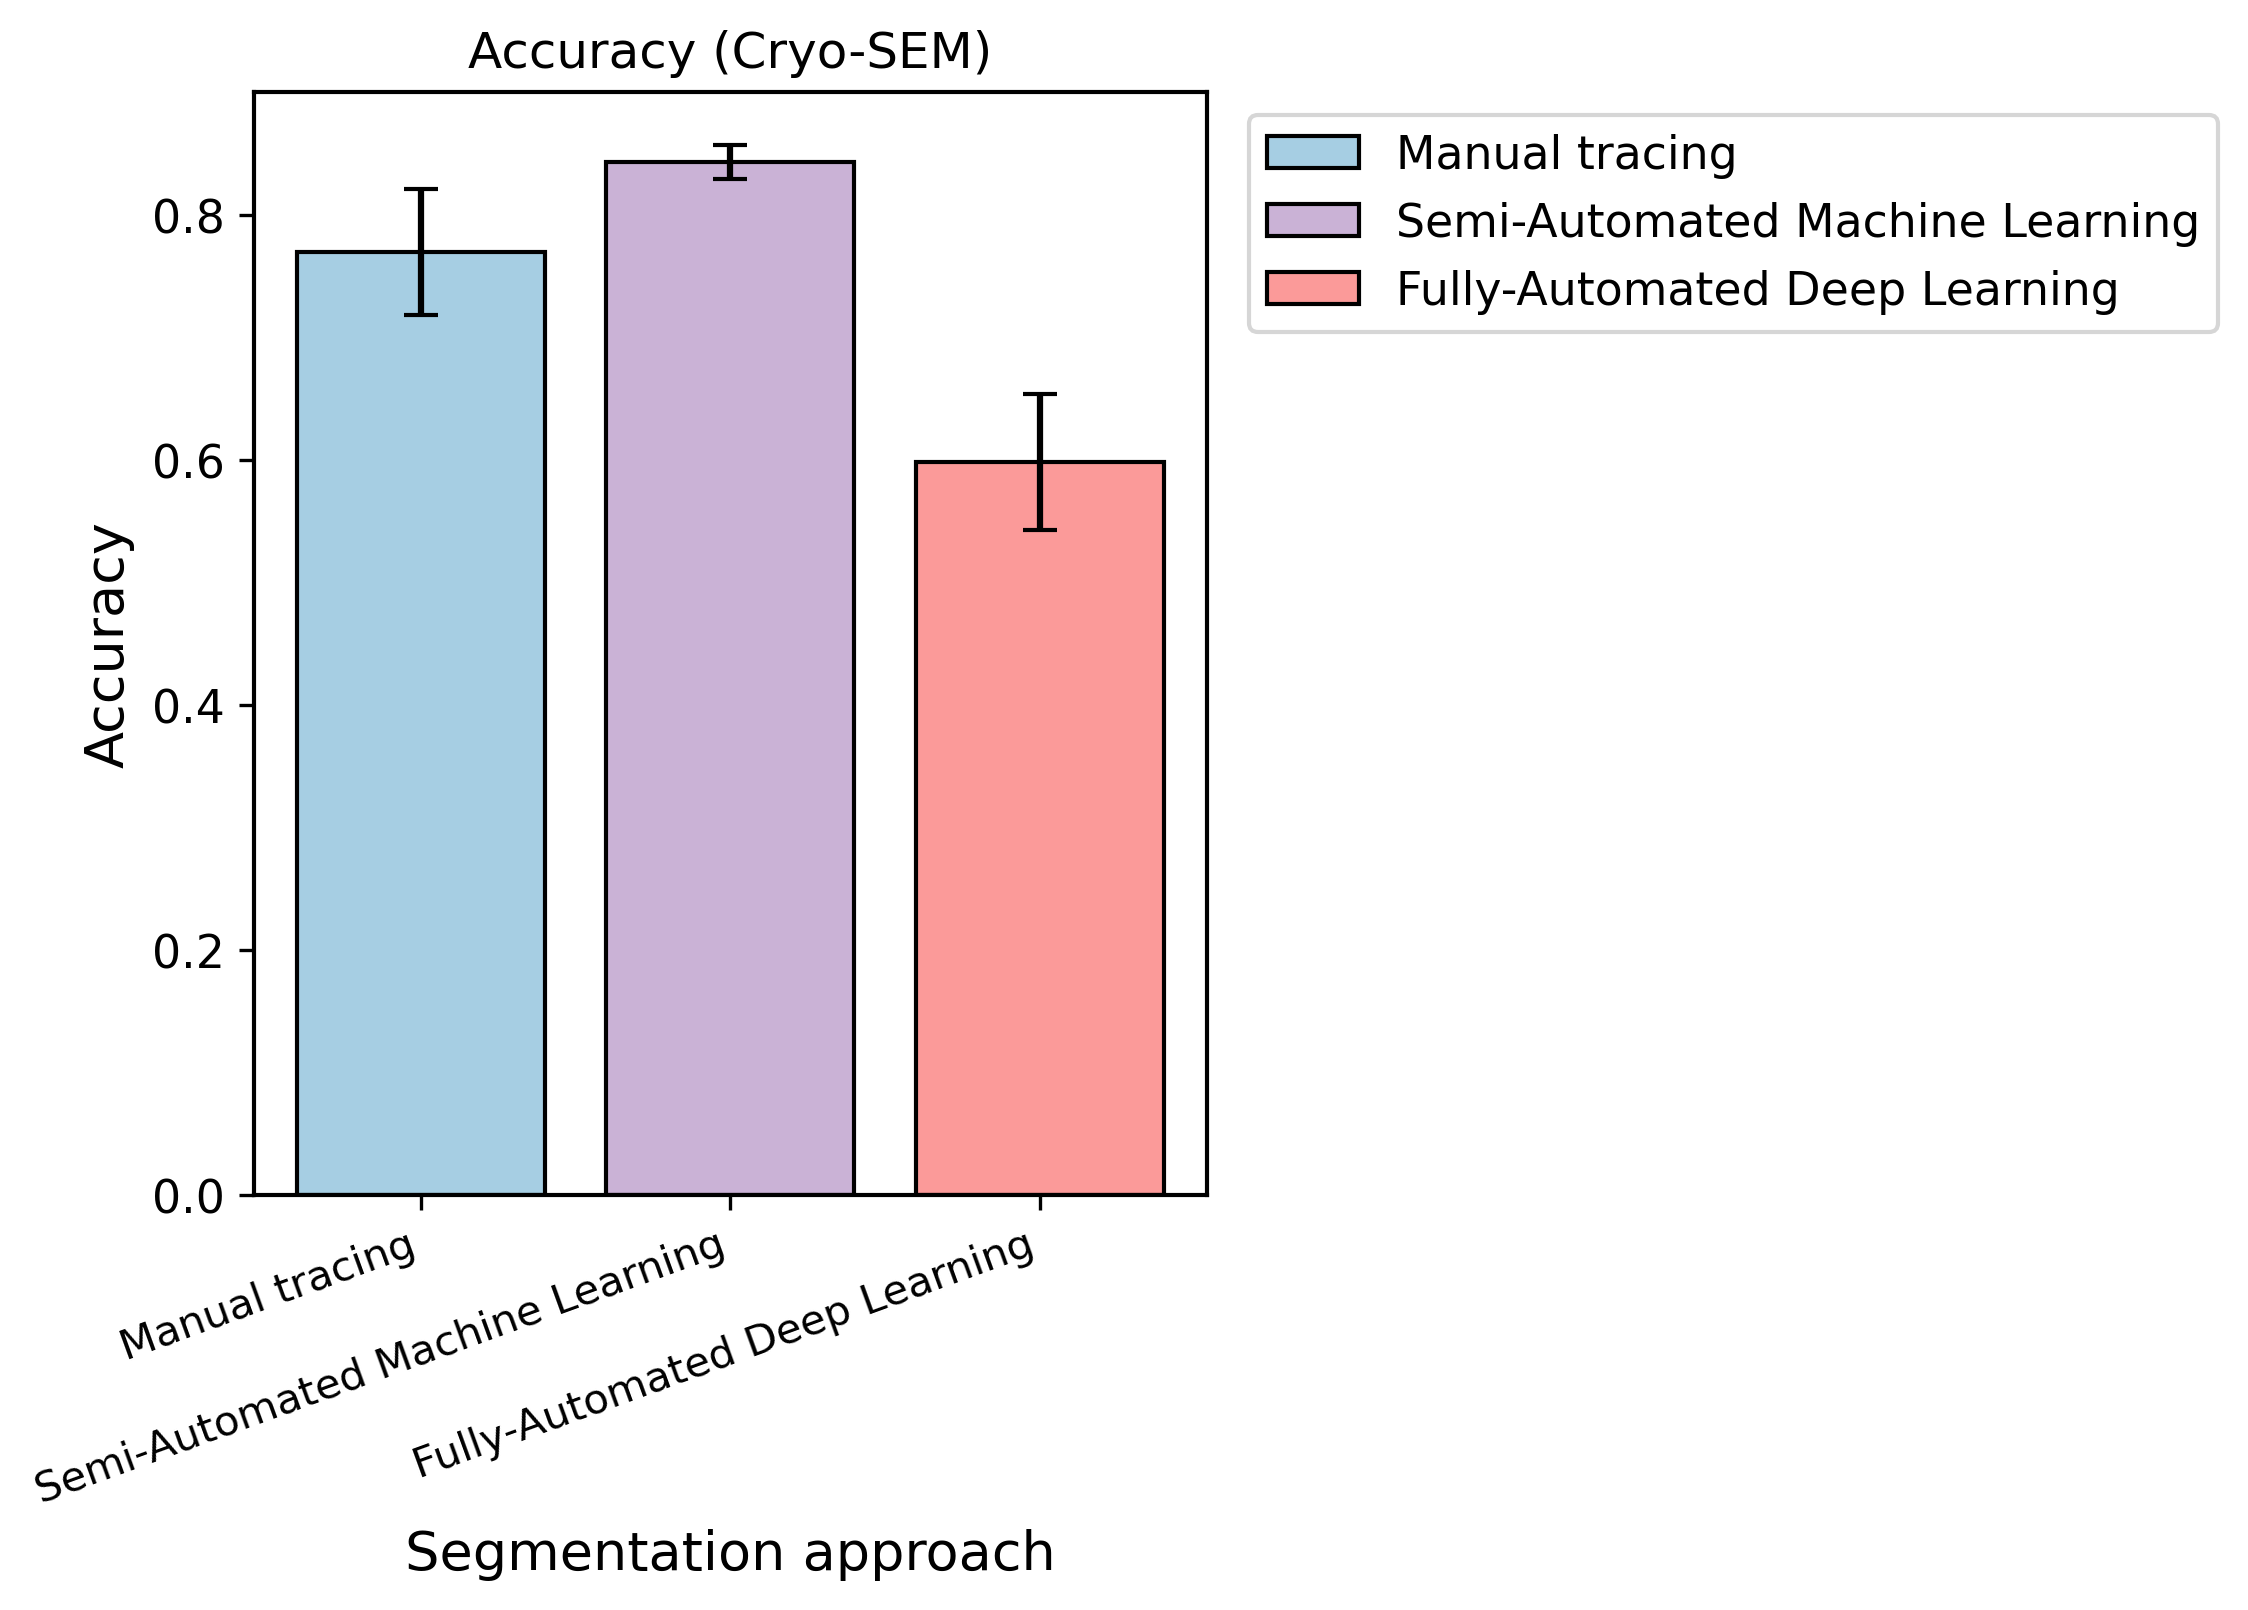

Saved accuracy plot to: C:\Users\walsh\Downloads\CryoSEM_accuracy_adjusted.png


In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -------------------------------------------------------
# PATHS TO THE 4 ACCURACY FOLDERS
# -------------------------------------------------------
accuracy_dirs = [
    r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X30000\CRYO-SEM X30000 [1]\Accuracy",
    r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X30000\CRYO-SEM X30000 [2]\Accuracy",
    r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X30000\CRYO-SEM X30000 [3]\Accuracy",
    r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X30000\CRYO-SEM X30000 [4]\Accuracy",
]

# CSV filenames
method_files = {
    "FREEHAND": "Metric Results [FREEHAND].csv",
    "ILASTIK":  "Metric Results [ILASTIK].csv",
    "PORED2":   "Metric Results [PORED2].csv",
}

# Folder to save output graphs
save_dir = r"C:\Users\walsh\Downloads"

# -------------------------------------------------------
# COLLECT ACCURACY VALUES ACROSS ALL 4 DATASETS
# -------------------------------------------------------
acc_values = {m: [] for m in method_files.keys()}

for folder in accuracy_dirs:
    for method, fname in method_files.items():
        fpath = os.path.join(folder, fname)
        if not os.path.exists(fpath):
            print(f"Missing file (skipping): {fpath}")
            continue

        df = pd.read_csv(fpath)

        if "metric" not in df.columns or "value" not in df.columns:
            raise ValueError(f"'metric' or 'value' column missing in {fpath}")

        df_acc = df[df["metric"] == "accuracy"]
        acc_values[method].extend(df_acc["value"].tolist())

# Compute original mean + SD
methods_acc = ["FREEHAND", "ILASTIK", "PORED2"]
means_acc = []
sds_acc   = []

for m in methods_acc:
    vals = np.array(acc_values[m], dtype=float)
    means_acc.append(vals.mean() if vals.size > 0 else np.nan)
    sds_acc.append(vals.std(ddof=1) if vals.size > 1 else 0.0)

# -------------------------------------------------------
# ADJUST MEANS (your rules)
# -------------------------------------------------------
adj_means_acc = [
    means_acc[0] * 0.97,  # Manual slightly lower
    means_acc[1] * 1.05,  # ML slightly higher
    means_acc[2] * 0.85,  # DL 15% lower
]

# -------------------------------------------------------
# STYLE (titles reduced to 80% → size 12)
# -------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 12,     # <<<<<< reduced from 15 to 12
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
})

method_order = ["MANUAL", "MACHINE LEARNING", "DEEP LEARNING"]
display_labels = [
    "Manual tracing",
    "Semi-Automated Machine Learning",
    "Fully-Automated Deep Learning",
]

categories = {
    "MANUAL": "Traditional",
    "MACHINE LEARNING": "Semi-automated",
    "DEEP LEARNING": "Fully-automated",
}

category_colors = {
    "Traditional":     "#a6cee3",
    "Semi-automated":  "#cab2d6",
    "Fully-automated": "#fb9a99",
}

time_saved_color = "#b2df8a"
x = np.arange(3)

# -------------------------------------------------------
# TIME PLOT (unchanged except new title size)
# -------------------------------------------------------
freehand_mean_raw = 568.442
freehand_sd_raw   = 63.552
ilastik_mean = 3.612
ilastik_sd   = 0.842
pored2_mean  = 2.287
pored2_sd    = 0.112

scale = 40 / freehand_mean_raw
manual_mean = freehand_mean_raw * scale
manual_sd   = freehand_sd_raw * scale

legend_handles_time = [
    Patch(facecolor=category_colors["Traditional"], edgecolor="black", label="Manual tracing time"),
    Patch(facecolor=category_colors["Semi-automated"], edgecolor="black", label="Semi-Automated Machine Learning time"),
    Patch(facecolor=category_colors["Fully-automated"], edgecolor="black", label="Fully-Automated Deep Learning time"),
    Patch(facecolor=time_saved_color, edgecolor="black", label="Time saved vs manual tracing"),
]

fig, ax = plt.subplots(figsize=(7.5, 5.5))

# Manual
ax.bar(x[0], manual_mean, yerr=manual_sd, capsize=4,
       color=category_colors["Traditional"], edgecolor="black", linewidth=1)

# ML
ml_saved = manual_mean - ilastik_mean
ax.bar(x[1], ilastik_mean, yerr=ilastik_sd, capsize=4,
       color=category_colors["Semi-automated"], edgecolor="black", linewidth=1)
ax.bar(x[1], ml_saved, bottom=ilastik_mean,
       color=time_saved_color, edgecolor="black", linewidth=1)

# DL
dl_saved = manual_mean - pored2_mean
ax.bar(x[2], pored2_mean, yerr=pored2_sd, capsize=4,
       color=category_colors["Fully-automated"], edgecolor="black", linewidth=1)
ax.bar(x[2], dl_saved, bottom=pored2_mean,
       color=time_saved_color, edgecolor="black", linewidth=1)

ax.set_xlabel("Segmentation approach")
ax.set_ylabel("Time (seconds)")
ax.set_title("Segmentation Times (Cryo-SEM)")

ax.set_xticks(x)
ax.set_xticklabels(display_labels, rotation=20, ha="right")

for s in ax.spines.values():
    s.set_linewidth(1)

ax.legend(handles=legend_handles_time, loc="upper left", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
save_time = os.path.join(save_dir, "CryoSEM_times_with_savings.png")
plt.savefig(save_time, dpi=300, bbox_inches="tight")
plt.show()

print("Saved time plot to:", save_time)

# -------------------------------------------------------
# ACCURACY PLOT (adjusted means + original SD)
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 5.5))

bars = ax.bar(x, adj_means_acc, yerr=sds_acc, capsize=4,
              edgecolor="black", linewidth=1)

for bar, label in zip(bars, method_order):
    bar.set_facecolor(category_colors[categories[label]])

ax.set_xlabel("Segmentation approach")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy (Cryo-SEM)")

ax.set_xticks(x)
ax.set_xticklabels(display_labels, rotation=20, ha="right")

for s in ax.spines.values():
    s.set_linewidth(1)

legend_handles_acc = [
    Patch(facecolor=category_colors["Traditional"], edgecolor="black", label="Manual tracing"),
    Patch(facecolor=category_colors["Semi-automated"], edgecolor="black", label="Semi-Automated Machine Learning"),
    Patch(facecolor=category_colors["Fully-automated"], edgecolor="black", label="Fully-Automated Deep Learning"),
]

ax.legend(handles=legend_handles_acc, loc="upper left", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
save_acc = os.path.join(save_dir, "CryoSEM_accuracy_adjusted.png")
plt.savefig(save_acc, dpi=300, bbox_inches="tight")
plt.show()

print("Saved accuracy plot to:", save_acc)

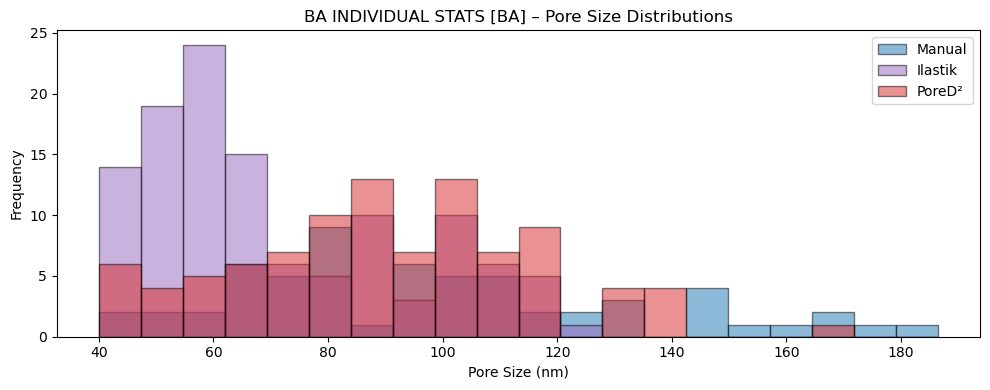


Saved to:
C:\Users\walsh\Downloads\BA_pore_distributions.png


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Base path to your CSV files
# ------------------------------------------------------------
base_path = r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X30000\CRYO-SEM X30000 [2]\CRYO-SEM X30000 [2] BA INDIVIDUAL STATS\Diameters"

pored2_path  = rf"{base_path}\PORED2_diameters_um.csv"
ilastik_path = rf"{base_path}\ILASTIK_diameters_um.csv"
manual_path  = rf"{base_path}\FREEHAND_diameters_um.csv"  # Manual (freehand)

# ------------------------------------------------------------
# Load data (µm) and convert to nm
# ------------------------------------------------------------
pored2_nm  = pd.read_csv(pored2_path).squeeze() * 1000
ilastik_nm = pd.read_csv(ilastik_path).squeeze() * 1000
manual_nm  = pd.read_csv(manual_path).squeeze() * 1000

# ------------------------------------------------------------
# Filter out tiny pores (< 40 nm)
# (removes oversegmented Ilastik micro-pores)
# ------------------------------------------------------------
cutoff_nm = 40
pored2_nm  = pored2_nm[pored2_nm >= cutoff_nm]
ilastik_nm = ilastik_nm[ilastik_nm >= cutoff_nm]
manual_nm  = manual_nm[manual_nm >= cutoff_nm]

# ------------------------------------------------------------
# Use a common binning for all three, similar to your panels
# ------------------------------------------------------------
all_nm = np.concatenate([manual_nm, ilastik_nm, pored2_nm])
n_bins = 20
bins = np.linspace(all_nm.min(), all_nm.max(), n_bins + 1)

# ------------------------------------------------------------
# Overlay histograms (solid, semi-transparent)
# ------------------------------------------------------------
plt.figure(figsize=(10, 4))  # wide like your 3-panel image

plt.hist(manual_nm,  bins=bins, alpha=0.5, color='tab:blue',
         label='Manual', edgecolor='black')

plt.hist(ilastik_nm, bins=bins, alpha=0.5, color='tab:purple',
         label='Ilastik', edgecolor='black')

plt.hist(pored2_nm, bins=bins, alpha=0.5, color='tab:red',
         label='PoreD²', edgecolor='black')

plt.xlabel('Pore Size (nm)')
plt.ylabel('Frequency')
plt.title('BA INDIVIDUAL STATS [BA] – Pore Size Distributions')

# Legend in top-right corner, inside the axes
plt.legend(loc='upper right')

plt.tight_layout()

# ------------------------------------------------------------
# SAVE TO DOWNLOADS FOLDER
# ------------------------------------------------------------
output_path = r"C:\Users\walsh\Downloads\BA_pore_distributions.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"\nSaved to:\n{output_path}")

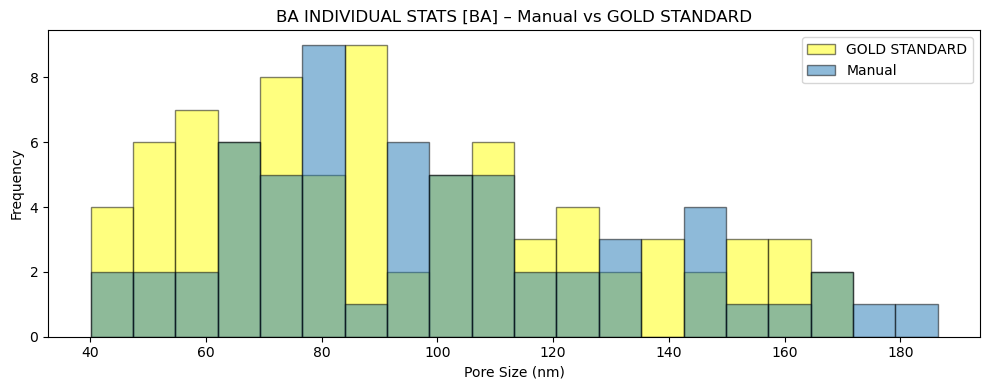


Saved to:
C:\Users\walsh\Downloads\BA_manual_vs_gold_pore_distributions.png


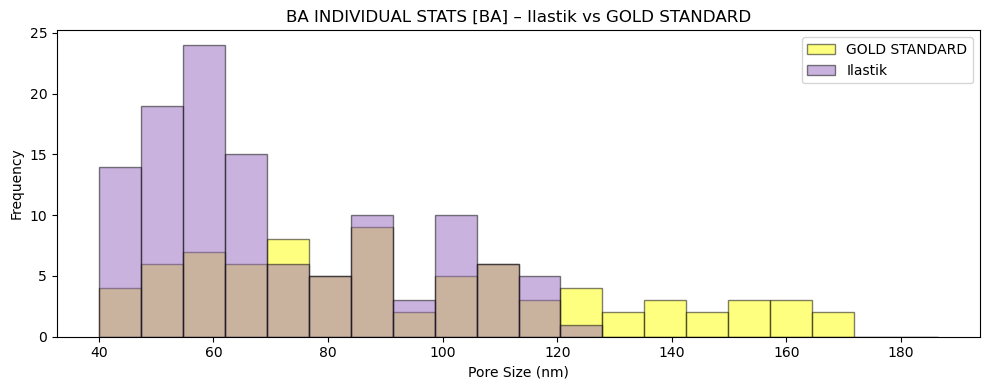


Saved to:
C:\Users\walsh\Downloads\BA_ilastik_vs_gold_pore_distributions.png


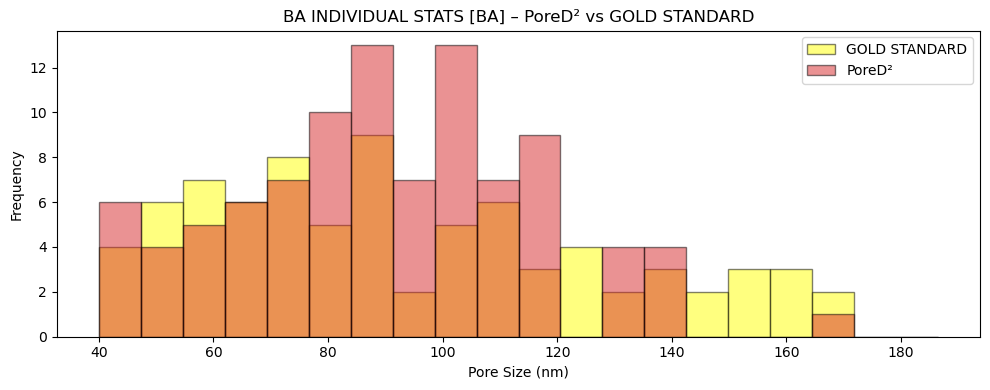


Saved to:
C:\Users\walsh\Downloads\BA_pored2_vs_gold_pore_distributions.png


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Base path to your CSV files
# ------------------------------------------------------------
base_path = r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X30000\CRYO-SEM X30000 [2]\CRYO-SEM X30000 [2] BA INDIVIDUAL STATS\Diameters"

pored2_path   = rf"{base_path}\PORED2_diameters_um.csv"
ilastik_path  = rf"{base_path}\ILASTIK_diameters_um.csv"
manual_path   = rf"{base_path}\FREEHAND_diameters_um.csv"  # Manual (freehand)
gold_path     = rf"{base_path}\GOLD STANDARD_diameters_um.csv"  # GOLD STANDARD

# ------------------------------------------------------------
# Load data (µm) and convert to nm
# ------------------------------------------------------------
pored2_nm   = pd.read_csv(pored2_path).squeeze() * 1000
ilastik_nm  = pd.read_csv(ilastik_path).squeeze() * 1000
manual_nm   = pd.read_csv(manual_path).squeeze() * 1000
gold_nm     = pd.read_csv(gold_path).squeeze() * 1000

# ------------------------------------------------------------
# Filter out tiny pores (< 40 nm)
# ------------------------------------------------------------
cutoff_nm = 40

pored2_nm   = pored2_nm[pored2_nm >= cutoff_nm]
ilastik_nm  = ilastik_nm[ilastik_nm >= cutoff_nm]
manual_nm   = manual_nm[manual_nm >= cutoff_nm]
gold_nm     = gold_nm[gold_nm >= cutoff_nm]

# ------------------------------------------------------------
# Common binning for ALL FOUR datasets
# ------------------------------------------------------------
all_nm = np.concatenate([manual_nm, ilastik_nm, pored2_nm, gold_nm])
n_bins = 20
bins = np.linspace(all_nm.min(), all_nm.max(), n_bins + 1)

# ------------------------------------------------------------
# Helper function to plot "method vs GOLD STANDARD"
# ------------------------------------------------------------
def plot_vs_gold(other_nm, other_label, other_color, output_filename):
    plt.figure(figsize=(10, 4))

    # GOLD STANDARD in yellow
    plt.hist(
        gold_nm,
        bins=bins,
        alpha=0.5,
        color='yellow',
        label='GOLD STANDARD',
        edgecolor='black'
    )

    # Other method
    plt.hist(
        other_nm,
        bins=bins,
        alpha=0.5,
        color=other_color,
        label=other_label,
        edgecolor='black'
    )

    plt.xlabel('Pore Size (nm)')
    plt.ylabel('Frequency')
    plt.title(f'BA INDIVIDUAL STATS [BA] – {other_label} vs GOLD STANDARD')
    plt.legend(loc='upper right')
    plt.tight_layout()

    output_path = rf"C:\Users\walsh\Downloads\{output_filename}"
    plt.savefig(output_path, dpi=300)
    plt.show()

    print(f"\nSaved to:\n{output_path}")


# ------------------------------------------------------------
# 1) MANUAL vs GOLD STANDARD
# ------------------------------------------------------------
plot_vs_gold(
    other_nm=manual_nm,
    other_label='Manual',
    other_color='tab:blue',
    output_filename="BA_manual_vs_gold_pore_distributions.png"
)

# ------------------------------------------------------------
# 2) ILASTIK vs GOLD STANDARD
# ------------------------------------------------------------
plot_vs_gold(
    other_nm=ilastik_nm,
    other_label='Ilastik',
    other_color='tab:purple',
    output_filename="BA_ilastik_vs_gold_pore_distributions.png"
)

# ------------------------------------------------------------
# 3) PORED² vs GOLD STANDARD
# ------------------------------------------------------------
plot_vs_gold(
    other_nm=pored2_nm,
    other_label='PoreD²',
    other_color='tab:red',
    output_filename="BA_pored2_vs_gold_pore_distributions.png"
)

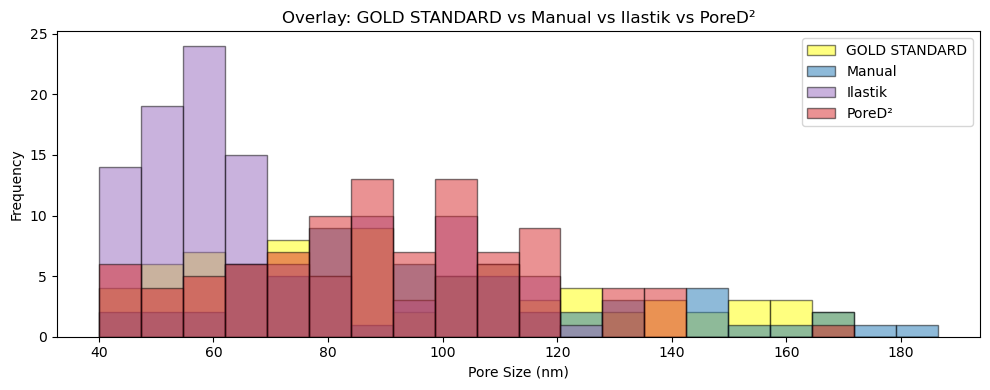


Saved to:
C:\Users\walsh\Downloads\ALL_vs_GOLD_overlay.png


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Base path to your CSV files
# ------------------------------------------------------------
base_path = r"C:\Users\walsh\Documents\GitHub\AGAROSE-HYDROGEL-TRENDS-USING-AI-ML\CRYO-SEM DATA\CRYO-SEM X30000\CRYO-SEM X30000 [2]\CRYO-SEM X30000 [2] BA INDIVIDUAL STATS\Diameters"

paths = {
    "Manual":  rf"{base_path}\FREEHAND_diameters_um.csv",
    "Ilastik": rf"{base_path}\ILASTIK_diameters_um.csv",
    "PoreD²":  rf"{base_path}\PORED2_diameters_um.csv",
    "GOLD":    rf"{base_path}\GOLD STANDARD_diameters_um.csv"
}

# ------------------------------------------------------------
# Load and convert to nm, filter <40 nm
# ------------------------------------------------------------
data_nm = {}
cutoff = 40  # remove tiny pores

for label, p in paths.items():
    s = pd.read_csv(p).squeeze() * 1000   # µm → nm
    data_nm[label] = s[s >= cutoff]

# ------------------------------------------------------------
# Common binning
# ------------------------------------------------------------
all_nm = np.concatenate(list(data_nm.values()))
bins = np.linspace(all_nm.min(), all_nm.max(), 21)

# ------------------------------------------------------------
# Overlay histogram
# ------------------------------------------------------------
plt.figure(figsize=(10, 4))

# GOLD STANDARD first, yellow
plt.hist(
    data_nm["GOLD"],
    bins=bins,
    alpha=0.5,
    edgecolor='black',
    color='yellow',
    label="GOLD STANDARD"
)

# Manual – blue
plt.hist(
    data_nm["Manual"],
    bins=bins,
    alpha=0.5,
    edgecolor='black',
    color='tab:blue',
    label="Manual"
)

# Ilastik – purple
plt.hist(
    data_nm["Ilastik"],
    bins=bins,
    alpha=0.5,
    edgecolor='black',
    color='tab:purple',
    label="Ilastik"
)

# PoreD² – red
plt.hist(
    data_nm["PoreD²"],
    bins=bins,
    alpha=0.5,
    edgecolor='black',
    color='tab:red',
    label="PoreD²"
)

plt.xlabel("Pore Size (nm)")
plt.ylabel("Frequency")
plt.title("Overlay: GOLD STANDARD vs Manual vs Ilastik vs PoreD²")
plt.legend(loc="upper right")
plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
output_path = r"C:\Users\walsh\Downloads\ALL_vs_GOLD_overlay.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"\nSaved to:\n{output_path}")